# Практическая работа №2. Исследование социально-демографической структуры общества США

<a id=content></a>
## Содержание
<br>[Описание проекта](#descr_proj)
<br>[Описание данных](#descr_data)
<br>
1. [<b>Загрузка данных и получение общей информации</b>](#1)
2. [<b>Предварительная обработка данных</b>](#2)
    <br>[2.1. Преобразование типов данных](#2.1.)
    <br>[2.2. Обработка пропущенных значений](#2.2.)
    <br>[2.3. Обработка дубликатов](#2.3.)
    <br>[2.4. Обработка аномальных значений](#2.4.)
3. [<b>Демографический портрет общества</b>](#3)
    <br>[3.1. Возрастная структура общества](#3.1)
    <br>[3.2. георграфия происхождения респондентов](#3.2)
    <br>[3.3. Совмещённое распределение расы и страны происхождения](#3.3)
4. [<b>Социально-экономическая стратификация</b>](#4)
    <br>[4.1. Влияние возраста на уровень дохода](#4.1)
    <br>[4.2. Тип занятости и уровень образования](#4.2)
    <br>[4.3. Уровень дохода по профессиям](#4.3)
5. [<b>Гендерное неравенство</b>](#5)
    <br>[5.1. Гендерный анализ доходов](#5.1)
    <br>[5.2. Гендерное неравенство в профессиях и уровню дохода](#5.2)
    <br>[5.3. Гендерное неравенство в уровне дохода и контексте образования](#5.3)
6. [<b>Расовое неравенство и сегрегация</b>](#6)
    <br>[6.1. Расовое неравенство в доходах](#6.1)
    <br>[6.2. Доступность образования для расовых групп](#6.2)
    <br>[6.3. Расовое неравенство в типах занятости](#6.3)
7. [<b>Семейная структура и её влияние</b>](#7)
    <br>[7.1. Влияние семейного положения на рабочие часы](#7.1)
    <br>[7.2. Влияние семейного положения на доход в разрезе гендерного признака](#7.2)
    <br>[7.3. Соотношение семейного положения и уровня дохода](#7.3)
    <br>[7.4. Влияние наличия детей на рабочие часы и уровень дохода](#7.4)
8. [<b>Финансовая уязвимость и капитал</b>](#8)
    <br>[8.1. Распределение доходов и потерь капитала в соответствии с типом занятости](#8.1)
    <br>[8.2. Возраст и финансовые проблемы](#8.2)
    <br>[8.3. Распределение капитала по уровню дохода](#8.3)
9. [<b>Интегральный анализ. Кто достигает успеха в обществе?</b>](#9)
    <br>[9.1. Комплексный  анализ заработка в зависимости от образования и возраста](#9.1)
    <br>[9.2. Многомерный анализ: образование, возраст, доход](#9.2)
    <br>[9.3. Факторы успеха: сводная таблица](#9.3)
    <br>[9.4. Статистический анализ: какие факторы наиболее значимы для уровня доходов?](#9.4)
    <br>[9.5. Портрет успешного респондента](#9.5)
10. [<b>Запись результатов в файл с разделителем</b>](#10)
11. [<b>Выводы</b>](#11)

<a id=descr_proj></a>
## Описание проекта
Требуется загрузить данные, выполнить их предварительную обработку и проверку на пропуски и аномальные значения, провести описательный анализ данных и ответить на ряд исследовательских вопросов. По итогам проведения работы необходимо выполнить запись результатов в файл с разделителями.

<a id=descr_data></a>
## Описание данных

Датасет собран на основе данных переписи населения США за 1994 год и содержит информацию о социально-демографических характеристиках респондентов. В датасете содержится 32 561 запись, каждая из которых описывает отдельного человека по 14 признакам. Среди них — возраст, пол, раса, страна рождения, семейное положение, уровень образования, профессия, количество рабочих часов в неделю, а также такие специфические переменные, как прирост или потеря капитала. Особняком стоит 15-й признак fnlwgt (`final weight`) — статистический вес, который указывает, скольким реальным людям в общей популяции соответствует данное наблюдение с точки зрения репрезентативности. Этот признак не имеет причинно-следственной связи с уровнем дохода, а лишь отражает методологию сбора данных переписи. `Целевая переменная` разбита на два класса: `≤50K` и `>50K`. Распределение между ними несбалансировано — около 76% респондентов относятся к первой группе.

Структура датасета:

|№ п/п|Наименование признака|Краткое описание|Единицы измерения|Диапазон значений|
|-----|:--------------------|:---------------|:---------------|:---------------|
|1.|`age`|возраст|год|от 17 до 90|
|2.|`workclass`|вид занятости|9 уникальных значений|<font color='red'><b>? </b></font>, индивидуальный предприниматель, самозанятый, работающий по трудовому договору, федеральный госслужащий, региональный госслужащий, муниципальный госслужащий, без оплаты труда, без опыта работы|
|3.|`fnlwgt`|статистический вес, назначенный каждому респонденту таким образом, чтобы представлять число людей, которых данный респондент "представляет" в общей популяции США (значение отражает сколько человек с аналогичным набором демографических характеристик (по мнению статистиков переписи) в реальной популяции соответствует данному наблюдению, чем выше `fnlwgt`, тем более "репрезентативен" данный случай).|21648 уникальных значений|от 12285 до 1484705|
|4.|`education`|образование|16 уникальных значений|детский сад, начальная школа (1-4 класс), начальная школа (5-6 класс), средняя школа (7-8 класс), старшая школа (9 класс), старшая школа (10 класс), старшая школа (11 класс), старшая школа (12 класс), абитуриент, техникум, колледж, среднее специальное образование технического профиля, среднее специальное образование гуманитарного (академического) профиля, бакалавр, магистр, доктор наук|
|5.|`education-num`|код образования|16 уникальных значений|от 1 до 16|
|6.|`marital-status`|семейное положение|7 уникальных значений|в браке с гражданским, в разводе, не вступал в брак, эмигрантская семья разделена, вдова или вдовец, в браке с военнослужащим (числится пропавшим без вести), в браке с военнослужащим (находится на службе в вооружённых силах)|
|7.|`occupation`|род деятельности|15 уникальных значений|<font color='red'><b>? </b></font>, техническая поддержка, механообработка и ремонт, прочие услуги, торговля, исполнительный менеджмент, специалист, клининговый сервис, оператор ПК, офисный работник, сельское хозяйство, транспортные услуги, услуги по уходу на дому, услуги по обеспечению охраны и безопасности, служба в вооружённых силах|
|8.|`relationship`|родственные связи|6 уникальных значений|жена, есть ребёнок, муж, сирота, иные родственники (бабушка, дедушка, брат, сестра, тётя, дядя), не женат|
|9.|`race`|раса|5 уникальных значений|европеец, житель азиатско-тихоокеанских островов, коренные народы Америки, иное, африканец|
|10.|`sex`|пол|2 уникальных значения|женщина, мужчина|
|11.|`capital-gain`|доход от капитала|122 уникальных значения|от 0 до 99999|
|12.|`capital-loss`|потери капитала|92 уникальных значения|от 0.0 до 4356.0|
|13.|`hours-per-week`|количество рабочих часов в неделю|94 уникальных значения|от 1 до 99|
|14.|`native-country`|место рождения|42 уникальные локации|<font color='red'><b>? </b></font>, США, Камбоджа, Англия, Пуэрто-Рико, Канада, Германия, Внешние малые острова США (Гуам, Американские Виргинские острова и д.р.), Индия, Япония, Греция, южные штаты США, Китай, Куба, Иран, Гондурас, Филиппины, Италия, Польша, Ямайка, Вьетнам, Мексика, Португалия, Ирландия, Франция, Доминиканская республика, Лаос, Эквадор, Тайвань, Гаити, Колумбия, Венгрия, Гватемала, Никарагуа, Шотландия, Тайланд, Югославия, Сальвадор, Тринидад и Тобаго, Перу, Гонконг, Голландия-Нидерланды |
|15.|`salary`|уровень дохода|2 категории|более 50 тыс., меньше или равно 50 тыс.|

Данные получены посредством последовательного применения методов `len()`, `unique()`, `min()`, `max()` к указанному датафрейму.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=1></a>
## Шаг 1. Загрузка данных и получение общей информации

In [1]:
# импортируем библиотеки для работы с массивами данных
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patheffects as path_effects
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
import squarify
np.random.seed(42)

# задаём пользовательские настройки вывода массива данных на экран
# максимально возможное количество столбцов - 100
pd.set_option("display.max_columns", 100)

# максимально возможное количество строк - 100
pd.set_option("display.max_rows", 100)

# округляем цифровые значения до 1 цифры после запятой, а не до 6 цифр по умолчанию
pd.set_option("display.precision", 1)

# игнорирование системных предупреждений об обновлениях работы функций
import warnings
warnings.simplefilter('ignore')

In [2]:
# загружаем исходный файл с массивом данных в переменную
adultdf = pd.read_csv('tgu_2_adult_data.csv')

In [3]:
# выводим на ознакомление описательную статистику
# параметр include="all" позволит вывести все значения: и числовые, и строковые
adultdf.describe(include="all")

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
count,32561.0,32561,3.3e+04,32561,32561.0,32561,32561,32561,32561,32561,32561,32554.0,32561.0,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,122,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,29846,NaN,NaN,29170,24720
mean,38.6,NaN,1.9e+05,NaN,10.1,NaN,NaN,NaN,NaN,NaN,NaN,87.3,40.4,NaN,NaN
std,13.6,NaN,1.1e+05,NaN,2.6,NaN,NaN,NaN,NaN,NaN,NaN,403.0,12.3,NaN,NaN
min,17.0,NaN,1.2e+04,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN
25%,28.0,NaN,1.2e+05,NaN,9.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,40.0,NaN,NaN
50%,37.0,NaN,1.8e+05,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,40.0,NaN,NaN
75%,48.0,NaN,2.4e+05,NaN,12.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,45.0,NaN,NaN


В этом массиве данных отсутствующие значения отмечены как `NaN`. Это строковое значение в Python, которое означает, что даже строки с числами будут храниться как типы данных `object`, потому что если в колонке есть какая-нибудь строковая, `pandas` конвертирует её в колонку, полностью состоящую из строковых.

In [4]:
# воспользуемся методом `info` для получения общей информации о полноте данных и их типах 
adultdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32561 non-null  int64  
 1   workclass       32561 non-null  object 
 2   fnlwgt          32561 non-null  int64  
 3   education       32561 non-null  object 
 4   education-num   32561 non-null  int64  
 5   marital-status  32561 non-null  object 
 6   occupation      32561 non-null  object 
 7   relationship    32561 non-null  object 
 8   race            32561 non-null  object 
 9   sex             32561 non-null  object 
 10  capital-gain    32561 non-null  object 
 11  capital-loss    32554 non-null  float64
 12  hours-per-week  32561 non-null  int64  
 13  native-country  32561 non-null  object 
 14  salary          32561 non-null  object 
dtypes: float64(1), int64(4), object(10)
memory usage: 3.7+ MB


In [5]:
# выводим размеры полученного массива данных в формате (количество строк, количество столбцов)
adultdf.shape

(32561, 15)

**Вывод:** На данном этапе работы нами выполнена загрузка банковских данных о жителях США размером 32 561 строк в разрезе 15 уникальных признаков. В полученном списке в столбце `capital-gain` мы видим тип данных `object` вместо ожидаемого `float64`. По признаку `capital-loss` имеются пропуски в количестве 7 строк. В дальнейшей работе мы можем удалить эти строки без существенных потерь в данных.

<a id=2></a>
## Шаг 2. Предварительная обработка данных

<a id=2.1.></a>
### 2.1. Преобразование типов данных

На этапе предвартельного знакомства с данными среди уникальных значений столбца `capital-gain` нами были выявлены строковые данные: `5o`, `5f`, `h7`. Необходимо удалить эти строки и преобразовать оставшиеся значения в числовой формат.

In [6]:
# выведем уникальные значения столбца capital-gain
adultdf['capital-gain'].unique()

array(['2174', '0', '14084', '5o', '5f', 'h7', '5013', '2407', '14344',
       '15024', '7688', '34095', '4064', '4386', '7298', '1409', '3674',
       '1055', '5178', '3464', '2050', '2176', '594', '20051', '6849',
       '4101', '1111', '8614', '3411', '2597', '25236', '4650', '9386',
       '2463', '3103', '10605', '2964', '3325', '2580', '3471', '4865',
       '99999', '6514', '1471', '2329', '2105', '2885', '25124', '10520',
       '2202', '2961', '27828', '6767', '2228', '1506', '13550', '2635',
       '5556', '4787', '3781', '3137', '3818', '3942', '914', '401',
       '2829', '2977', '4934', '2062', '2354', '5455', '15020', '1424',
       '3273', '22040', '4416', '3908', '10566', '991', '4931', '1086',
       '7430', '6497', '114', '7896', '2346', '3418', '3432', '2907',
       '1151', '2414', '2290', '15831', '41310', '4508', '2538', '3456',
       '6418', '1848', '3887', '5721', '9562', '1455', '2036', '1831',
       '11678', '2936', '2993', '7443', '6360', '1797', '1173', '4

In [7]:
# убираем из датафрейма строки признака `capital-gain` с ошибочными данными
wrong_data = ['5o', '5f', 'h7']
adultdf = adultdf[~adultdf['capital-gain'].isin(wrong_data)]

In [8]:
# переводим очищенные данные по признаку `capital-gain` в числовой формат
adultdf['capital-gain'] = adultdf['capital-gain'].astype(float)

In [9]:
# проверка результатов преобразований
adultdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32557 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32557 non-null  int64  
 1   workclass       32557 non-null  object 
 2   fnlwgt          32557 non-null  int64  
 3   education       32557 non-null  object 
 4   education-num   32557 non-null  int64  
 5   marital-status  32557 non-null  object 
 6   occupation      32557 non-null  object 
 7   relationship    32557 non-null  object 
 8   race            32557 non-null  object 
 9   sex             32557 non-null  object 
 10  capital-gain    32557 non-null  float64
 11  capital-loss    32550 non-null  float64
 12  hours-per-week  32557 non-null  int64  
 13  native-country  32557 non-null  object 
 14  salary          32557 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 4.0+ MB


<a id=2.2.></a>
### 2.2. Обработка пропущенных значений

Необходимо выяснить, какое количество данных отсутствует в каждом признаке. И после этого принять решение об удалении этих столбцов, либо об их заполнении.

In [10]:
# вызываем функцию для вычисления отсутствующих значений по столбцу
def missing_values_table(adultdf):
        # вычислим общее количество пропущенных значений
        mis_val = adultdf.isnull().sum()
        
        # вычислим процент пропущенных значений
        mis_val_percent = 100 * adultdf.isnull().sum() / len(adultdf)
        
        # составим таблицу с результатами
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # переименуем столбцы
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Пропущенные значения составляют', 1 : '% от общего значения'})
        
        # отсортиреум таблицу по проценту пропуска по убыванию
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% от общего значения', ascending=False).round(2)
        
        # выводим промежуточную сводную информацию
        print ("Этот набор данных имеет " + str(adultdf.shape[1]) + " столбцов.\n"      
            "Количество столбцов  с пропущенными значениями: " + str(mis_val_table_ren_columns.shape[0]))
        
        # возвращаем dataframe с отсутствующими значениями
        return mis_val_table_ren_columns

In [11]:
# вызываем функцию для вывода промежуточной сводной информации об отсутствующих значениях
missing_values_table(adultdf)

Этот набор данных имеет 15 столбцов.
Количество столбцов  с пропущенными значениями: 1


,Пропущенные значения составляют,% от общего значения
capital-loss,7,2.0e-02


In [12]:
# удаляем пропуски по признаку `capital-loss`
adultdf = adultdf.dropna(subset=['capital-loss'])

Из числа неявных пропусков в данных на этапе предварительного знакомства с массивом информации мы также можем отметить неявные пропуски, а именно значения `?` по признаку `workclass` (вид занятости), по признаку `native-country` (место рождения) и по роду занятий `occupation`.

In [13]:
# подсчёт количества строк с пропусками данных сразу по трём признакам
len(adultdf[(adultdf['workclass'] == '?') & (adultdf['native-country'] == '?') & (adultdf['occupation'] == '?')])

27

Поскольку заполнение данных пропусков по категориям синтетическими данными приведёт к преднамеренному искажению информации, то мы вынуждены удалить данные строки из исследования.

In [14]:
# удаление пропусков по признакам `workclass`, `native-country` и `occupation`
adultdf = adultdf[(adultdf['workclass'] != '?') & (adultdf['native-country'] != '?') & (adultdf['occupation'] != '?')]

<a id=2.3.></a>
### 2.3. Обработка дубликатов

In [15]:
# выявление полных дубликатов
adultdf.duplicated().sum()

np.int64(23)

In [16]:
# удаление полных дубликатов
adultdf.drop_duplicates(inplace=True)

In [17]:
# проверка результатов преобразований
adultdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30129 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             30129 non-null  int64  
 1   workclass       30129 non-null  object 
 2   fnlwgt          30129 non-null  int64  
 3   education       30129 non-null  object 
 4   education-num   30129 non-null  int64  
 5   marital-status  30129 non-null  object 
 6   occupation      30129 non-null  object 
 7   relationship    30129 non-null  object 
 8   race            30129 non-null  object 
 9   sex             30129 non-null  object 
 10  capital-gain    30129 non-null  float64
 11  capital-loss    30129 non-null  float64
 12  hours-per-week  30129 non-null  int64  
 13  native-country  30129 non-null  object 
 14  salary          30129 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 3.7+ MB


<a id=2.4.></a>
### 2.4. Обработка аномальных значений

Основными и взаимодополняющими инструментами для выявления аномалий в данных являются графики типа `boxplot` и `KDE-plot (в сочетании с гистограммой)`
`Boxplot` наглядно показывает выбросы через межквартильный размах и границы усов, позволяя быстро обнаружить экстремальные значения. `KDE-plot с гистограммой` отображает форму распределения: аномалии могут проявляться как неожиданные пики, тяжёлые хвосты или области с нулевой плотностью, где данные всё же присутствуют. Совместное использование этих графиков даёт как статистическое (через квартили и границы), так и визуальное (через плотность и частоту) понимание структуры данных, что повышает надёжность обнаружения нетипичных наблюдений. Общие тенденции и аномалии в данных будут на таком графике будут выглядеть как сглаживание данных, которое может быть неочевидным на других диаграммах.

In [18]:
# формируем список количественных признаков, по которым будем выявлять аномалии
columns = ['age', 'hours-per-week', 'education-num', 'capital-gain', 'capital-loss', 'fnlwgt']

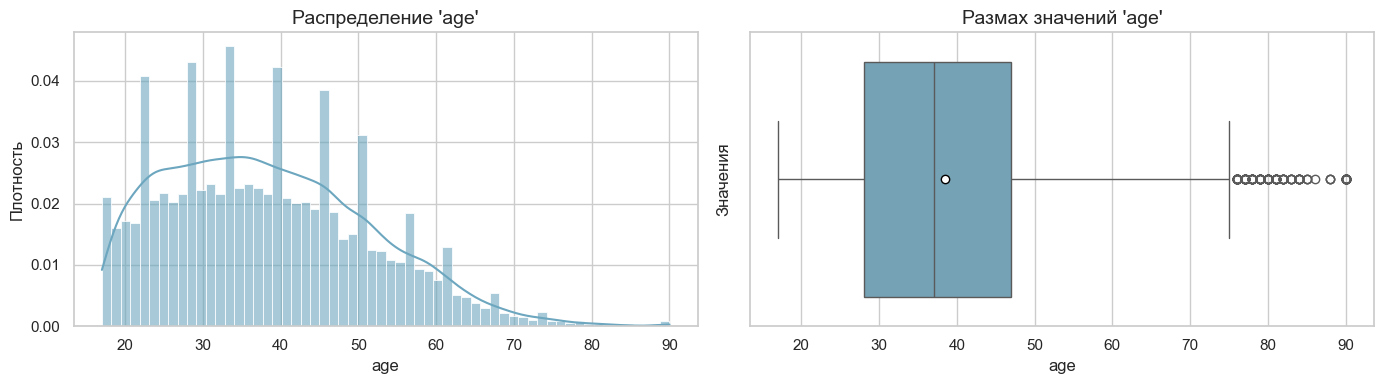

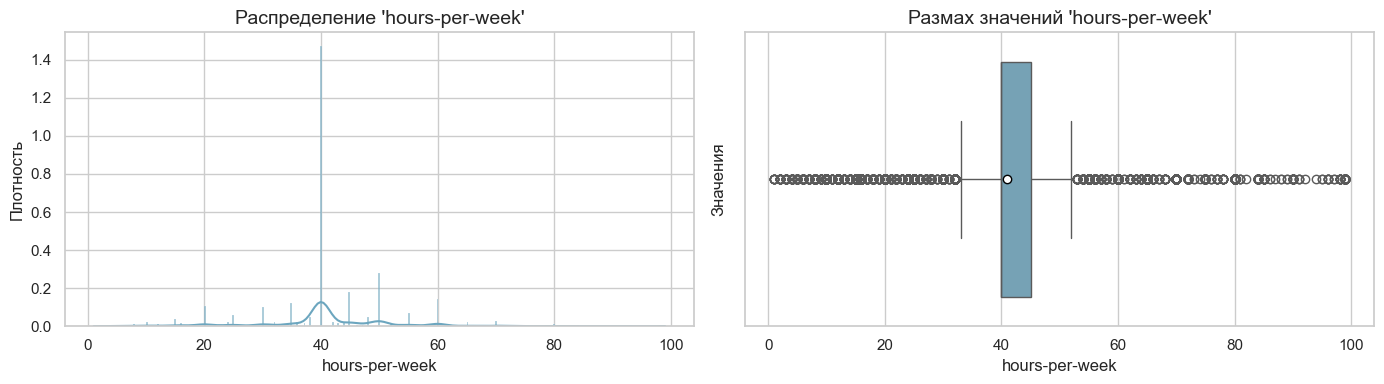

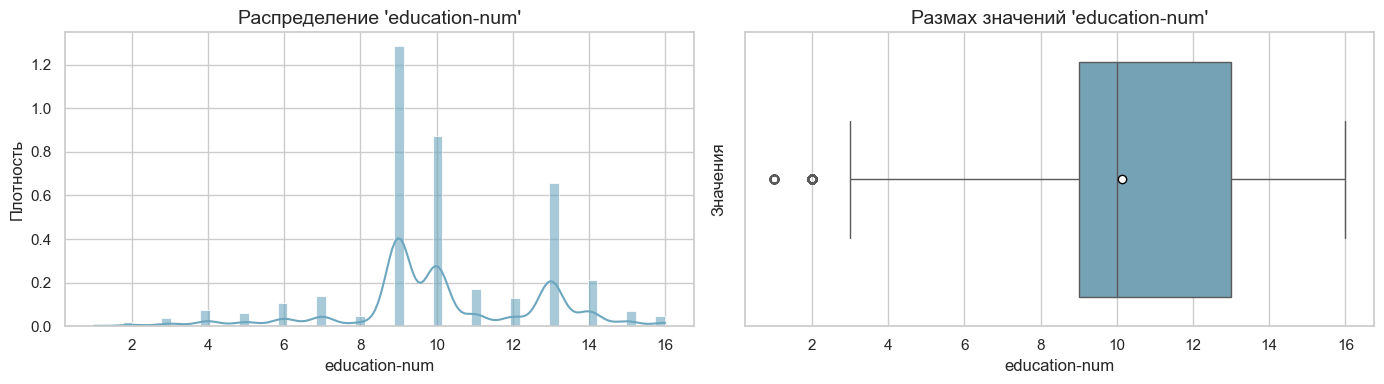

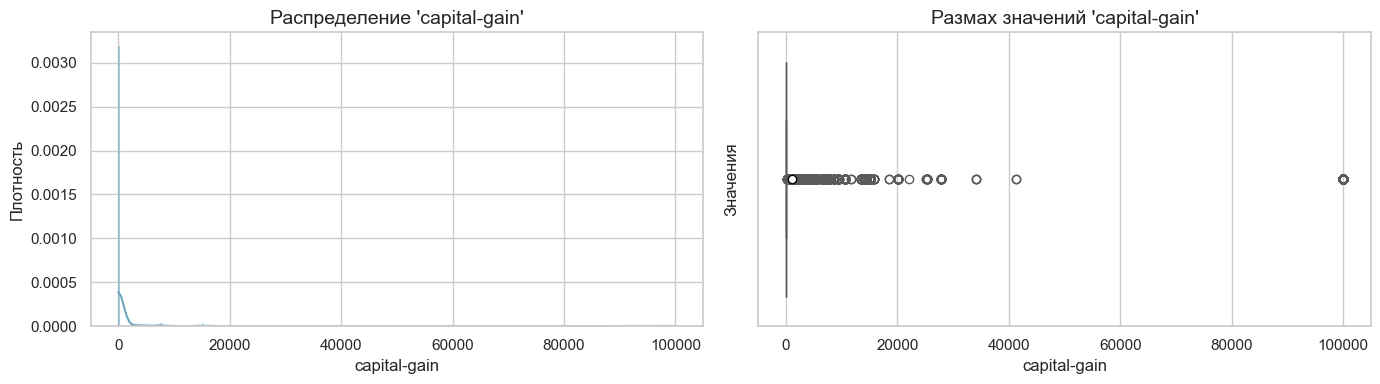

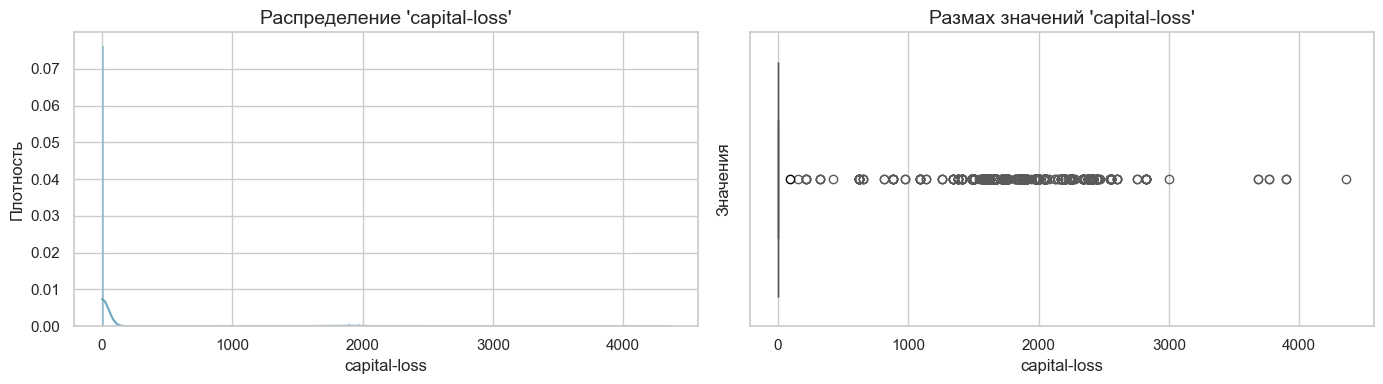

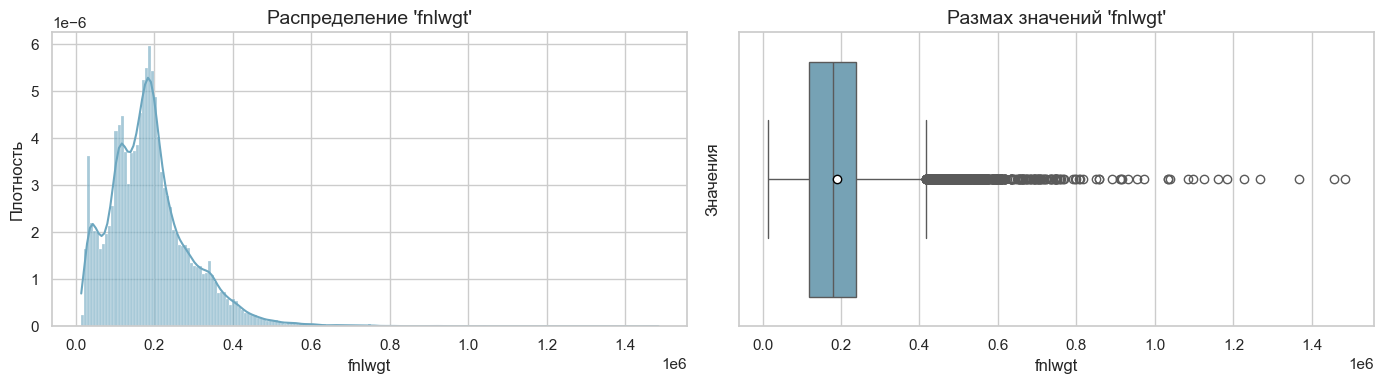

In [19]:
# парные графики
sns.set(style='whitegrid')

for column in columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # левый график: гистограмма + KDE
    # гистограмма
    sns.histplot(data=adultdf, x=column, kde=True, ax=axes[0], color='#6CA6BF', alpha=0.6, stat='density')
    axes[0].set_title(f"Распределение '{column}'", fontsize=14)
    axes[0].set_xlabel(column, fontsize=12)
    axes[0].set_ylabel('Плотность', fontsize=12)
    
    # правый график: boxplot
    sns.boxplot(data=adultdf, x=column, ax=axes[1], color='#6CA6BF', showmeans=True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"6"})
    axes[1].set_title(f"Размах значений '{column}'", fontsize=14)
    axes[1].set_xlabel(column, fontsize=12)
    axes[1].set_ylabel('Значения', fontsize=12)
    
    plt.tight_layout()
    plt.show()

Для полноты картины создадим таблицу с расширенными описательными стаистиками количественных признаков. Для этого расчитаем медианные значения, а также значения 95-го и 99-го перцентиля и коэффициента вариации, который позволит нам оценить изменчивость данных в процентах от среднего значения. Для этого рассчитаем коэффициент вариации для каждого набора данных: разделим стандартное отклонение (показатель разброса данных) на среднее значение и умножим на 100.

In [20]:
# фомируем расширенные описательные статистики количественных признаков
adultdf_descr = adultdf[['age', 'hours-per-week', 'education-num', 'capital-gain', 'capital-loss', 'fnlwgt']].describe()
coef_variation = adultdf[['age', 'hours-per-week', 'education-num', 'capital-gain', 'capital-loss', 'fnlwgt']].std() / adultdf[['age', 'hours-per-week', 'education-num', 'capital-gain', 'capital-loss', 'fnlwgt']].mean() * 100

columns_num = ['age', 'hours-per-week', 'education-num', 'capital-gain', 'capital-loss', 'fnlwgt']
for column in columns_num:
    adultdf_descr.loc['median', column] = adultdf[column].median()
    adultdf_descr.loc['95%', column] = adultdf[column].quantile(0.95)
    adultdf_descr.loc['99%', column] = adultdf[column].quantile(0.99)
    adultdf_descr.loc['coef_variation'] = coef_variation

# изменяем порядок индекса
new_index = ['count', 'coef_variation', 'std', 'mean', 'median', 'min', '25%', '50%', '75%', '95%', '99%', 'max']
adultdf_descr = adultdf_descr.reindex(new_index)
adultdf_descr

,age,hours-per-week,education-num,capital-gain,capital-loss,fnlwgt
count,30129.0,30129.0,30129.0,30129.0,30129.0,3.0e+04
coef_variation,34.2,29.3,25.2,678.0,457.2,5.6e+01
std,13.1,12.0,2.5,7410.3,404.5,1.1e+05
mean,38.4,40.9,10.1,1093.0,88.5,1.9e+05
median,37.0,40.0,10.0,0.0,0.0,1.8e+05
min,17.0,1.0,1.0,0.0,0.0,1.4e+04
25%,28.0,40.0,9.0,0.0,0.0,1.2e+05
50%,37.0,40.0,10.0,0.0,0.0,1.8e+05
75%,47.0,45.0,13.0,0.0,0.0,2.4e+05
95%,62.0,60.0,14.0,5013.0,0.0,3.8e+05


**Выводы:** 

* признак `age` (возраст) охватывает довольно широкий диапазон значений, но сосредоточен в основном на трудоспособной части населения без ярко выраженных аномалий. Средний возраст составляет 38.4 года, медиана 37 лет, что указывает на умеренное правое (положительное) смещение распределение, то есть немного больше людей старше среднего возраста. Основная масса респондентов находится в возрасте от 20 до 45 лет.
* признак `hours-per-week` (количество рабочих часов в неделю). Среднее значение находится рядом с медианным и составляет 40.9 часов в неделю, что соответствует стандартной полной занятости (5 дней в неделю по 8 часов). 25% квантиль также равна 40, что говорит о том, что значительная часть выборки работает ровно 40 часов. Максимум — 99 часов, 99-й перцентиль — 80 часов: встречаются случаи сверхурочной или ненормированной работы, но они редки. Коэффициент вариации (29.3%) свидетельствует об умеренной дисперсии, хотя большинство значений сконцентрировано около 40 часов. Таким образом, кроме доминирующей нагрузки в 40 часов в неделю, есть ещ ёодна подгруппа респондентов с высокой рабочей нагрузкой.
* признак `education-num` (код уровня образования) синхронно с признаком `education` описывает образование респондентов. Среднее практически с медианой составляет 10 - это выпускники колледжей. Минимальное пороговое значение зафикисровано в данных и соответствует уровню дошкольной начальной подготовки. Максимум соотносится с докторской степенью. 75% квантиль находится на отметке 13 - это бакалавриат. Коэффициент вариации (25.2%) показывает относительно низкую дисперсию: большинство респондентов имеют образование в диапазоне от 9 до 14 (выпускник старшей школы или колледжа, среднее специальное образование технического профиля, среднее специальное образование гуманитарного (академического) профиля, бакалавр, магистр). В целом, распределение образования сбалансировано, с умеренным числом высококвалифицированных специалистов, но без значительного перекоса в сторону высшего образования.
* доход от капитала `capital-gain` демонстирует крайне неравномерные значения. Среднее значение равно 1093, но при этом медиана равна нулю, равно как и 25%, 50%, 75% квантили. Это означает, что большинство людей (более 75% респондентов) вообще не имеют никаких доходов от вложений. 95-й перцентиль — 5013, 99-й — 15024, максимум — 99999. Это указывает на сильное правое смещение: небольшая группа лиц получает значительный доход от капитала. Коэффициент вариации (678%) чрезвычайно высок, подтверждая наличие редких, но очень больших значений (выбросов или реальных редких случаев). Стандартное отклонение (7410) также значительно превышает среднее. Подавляющее большинство нулевое, но присутствуют Редкие очень высокие значения доходов от капитала являются исключением из общего правила нулевых доходов.
* признак потери капитала `capital-loss` изобилует нулевыми значениями и это говорит о крайней степени разреженности значений. Среднее (88.5) сильно занижено относительно возможного максимума, что типично при таких распределениях, коэффициент вариации (457%) также очень высок из-за сильной нулевой концентрации и редких ненулевых значений. Медиана = 0, как и до 95-го перцентиля — большинство респондентов не несут никаких потерь капитала. 99-й перцентиль — 1980, максимум — 4356: потери, если и есть, то у очень немногих и в умеренных размерах.
* признак `fnlwgt`, используемый при опросах для репрезентативности, является по своей сути не признаком, а именно весом наблюдений. Среднее — 190 000, медиана — 180 000, максимум — 1.5 млн. Коэффициент вариации (56%) — умеренно высокая изменчивость, что нормально для весов. Перцентили показывают, что большинство весов лежат в диапазоне от 120 000 до 380 000. Распределение весов типично для сложных опросных данных.

Таким образом, в датасете присуствуют резко асимметричные признаки (`capital-gain`, `capital-loss`), требующие особого внимания при исследовании. Признаки `age`, `hours-per-week`, `education-num` имеют умеренную дисперсию. Большинство наблюдений по признакам наличия / отсутствия доходов от капитала может указывать на преобладание наёмных работников без каких-либо инвестиций. Признак `fnlwgt` не информативен и служит только для статистической репрезентативности выборки.

<a id=3></a>
## Шаг 3. Демографический портрет общества

<a id=3.1.></a>
### 3.1. Возрастная структура общества

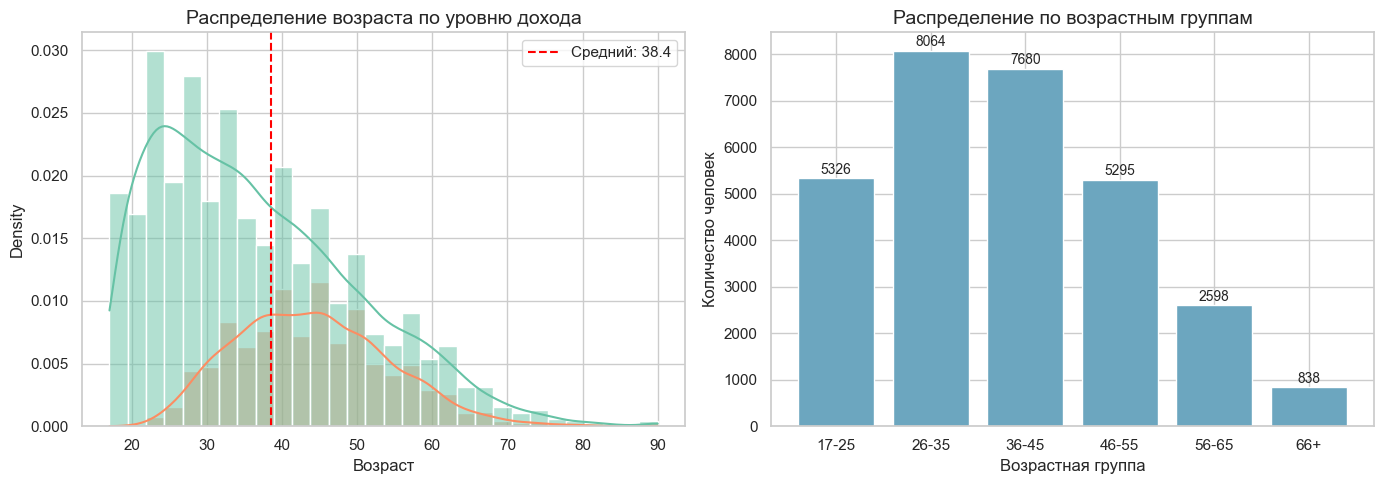

In [21]:
# визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# распределение возраста с разделением по доходу
sns.histplot(data=adultdf, x='age', hue='salary', bins=30, kde=True, ax=axes[0], palette='Set2', stat='density')

axes[0].set_title('Распределение возраста по уровню дохода', fontsize=14)
axes[0].set_xlabel('Возраст')
axes[0].axvline(adultdf['age'].mean(), color='red', linestyle='--', label=f'Средний: {adultdf["age"].mean():.1f}')
axes[0].legend()

# возрастные группы: бинаризация
age_bins = [17, 25, 35, 45, 55, 65, 90]
age_labels = ['17-25', '26-35', '36-45', '46-55', '56-65', '66+']
adultdf['age_group'] = pd.cut(adultdf['age'], bins=age_bins, labels=age_labels)
age_dist = adultdf['age_group'].value_counts().sort_index()

axes[1].bar(age_dist.index, age_dist.values, color='#6CA6BF')
axes[1].set_title('Распределение по возрастным группам', fontsize=14)
axes[1].set_xlabel('Возрастная группа')
axes[1].set_ylabel('Количество человек')

for i, v in enumerate(age_dist.values):
    axes[1].text(i, v + 100, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Анализ возрастной структуры общества на основе данных переписи демонстрирует, что ядро выборки составляют люди трудоспособного возраста, преимущественно в диапазоне от 20 до 45 лет, при этом общее распределение имеет легкое правое смещение. Средний возраст респондентов составляет около 38 лет, что отражает зрелость рабочей силы. Наблюдается четкая корреляция между возрастом и финансовым благополучием: пик вероятности получения высокого дохода приходится на период зрелости (от 36 до 55 лет), когда накапливается профессиональный опыт, укрепляются связи и достигается карьерная вершина.

В то же время молодые специалисты в возрасте до 25 лет статистически чаще оказываются в группе с низким доходом, что обусловлено их выходом на рынок труда, отсутствием стажа и начальными позициями. Люди предпенсионного и пенсионного возраста (старше 65 лет) также демонстрируют снижение финансовых показателей, что отражает естественные циклы трудовой активности, переход на частичную занятость или полный выход на пенсию. Таким образом, возраст выступает не просто демографической характеристикой, а фундаментальным фактором, определяющим экономический потенциал и положение индивида в социальной иерархии.

<a id=3.2.></a>
### 3.2. География происхождения респондентов

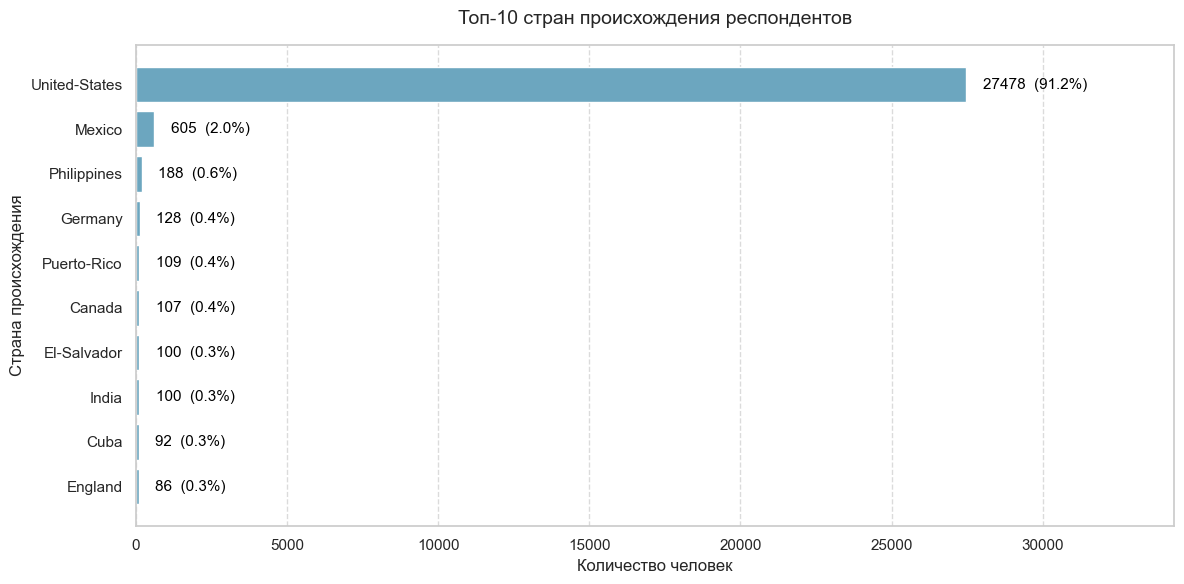

In [22]:
# визуализация: топ-10 стран происхождения
top_countries = adultdf['native-country'].value_counts().head(10)

# рассчитываем долю каждой страны от общего числа респондентов
total_count = adultdf.shape[0]
percentages = (top_countries.values / total_count) * 100

# создаём фигуру с увеличенной шириной, чтобы подписи не налезили
fig, ax = plt.subplots(figsize=(12, 6))

# горизонтальный барчарт
bars = ax.barh(top_countries.index, top_countries.values, color='#6CA6BF')

# инвертируем ось Y, чтобы первая страна была сверху
ax.invert_yaxis()

# оформление
ax.set_title('Топ-10 стран происхождения респондентов', fontsize=14, pad=15)
ax.set_xlabel('Количество человек', fontsize=12)
ax.set_ylabel('Страна происхождения', fontsize=12)

# устанавливаем xlim с запасом справа, чтобы подписи поместились
max_val = top_countries.values.max()
ax.set_xlim(0, max_val * 1.25)

# подписи справа от столбцов: "количество (доля %)"
for i, (val, pct) in enumerate(zip(top_countries.values, percentages)):
    ax.text(val + max_val * 0.02, i, f'{val}  ({pct:.1f}%)', va='center', fontsize=11, color='black')

# убираем горизонтальные линии сетк, вертикальные оставляем
ax.yaxis.grid(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Проведенный анализ фокусируется на географии происхождения респондентов выявил абсолютное доминирование уроженцев Соединенных Штатов, которые составляют подавляющее большинство выборки. Однако наличие значительной иммигрантской диаспоры позволяет проследить влияние культурного и географического бэкграунда на социально-экономический статус. В топ-10 стран происхождения, помимо США, входят Мексика, Филиппины, Германия, Канада и Индия, что отражает исторические волны миграции и экономические связи конца XX века.

Распределение иммигрантов по уровню дохода крайне неоднородно и напрямую зависит от страны их изначального пребывания. Уроженцы развитых стран с высоким уровнем человеческого капитала, таких как Канада, Германия или Франция, демонстрируют показатели дохода, сопоставимые или даже превышающие средние по выборке. В то же время выходцы из развивающихся государств, в частности из Мексики и стран Латинской Америки, статистически чаще оказываются в уязвимом финансовом положении, занимая ниши с низкой оплатой труда. Это подчеркивает, что страна происхождения выступает мощным прокси-переменной, отражающей стартовые условия, уровень начального образования и социальные сети, которые иммигранты привозят с собой.

<a id=3.3.></a>
### 3.3. Совмещённое распределение расы и страны происхождения

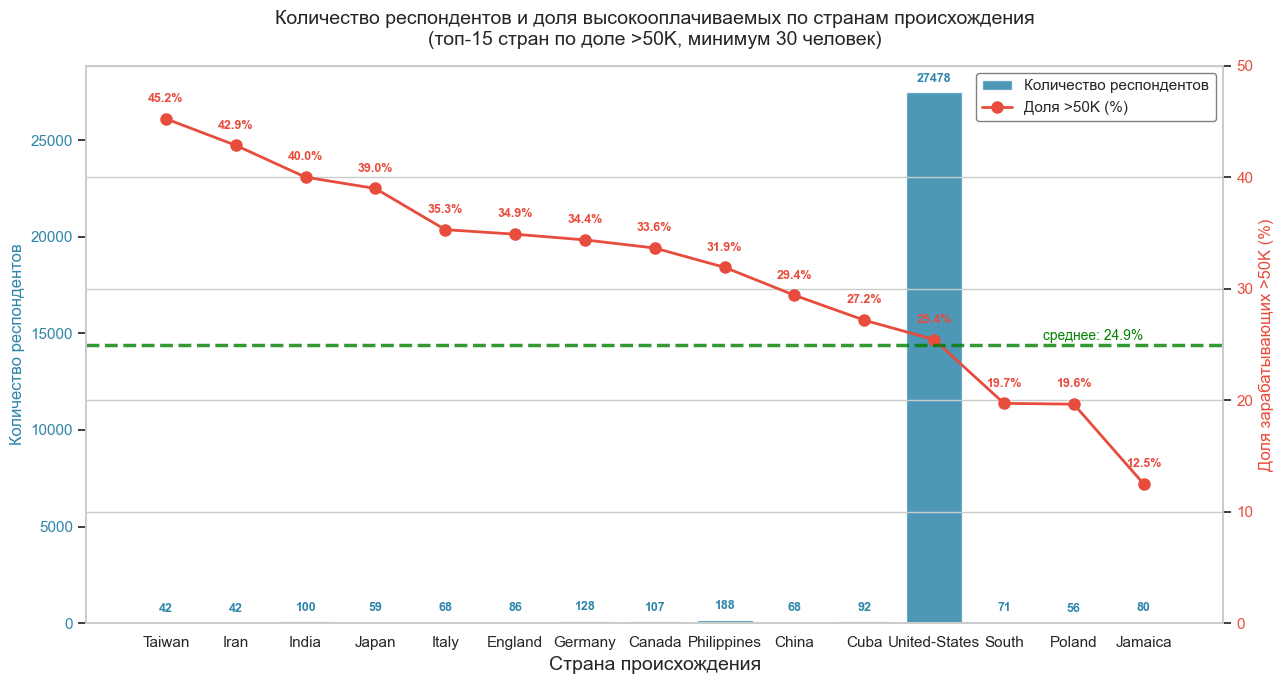

In [23]:
# фильтр по минимальному количеству представителей
country_counts = adultdf['native-country'].value_counts()
top_countries = country_counts[country_counts >= 30].index.tolist()
df_filtered = adultdf[adultdf['native-country'].isin(top_countries)]

# Считаем две метрики: общее количество и долю >50K
country_stats = df_filtered.groupby('native-country').agg(total_count=('salary', 'count'), high_salary_pct=('salary', lambda x: (x == '>50K').mean() * 100)).reset_index()

# сортируем по доле высокооплачиваемых
country_stats = country_stats.sort_values('high_salary_pct', ascending=False).head(15)

# визуализация с двумя осями
fig, ax1 = plt.subplots(figsize=(13, 7))

# Столбцы — количество людей (более тёмный синий цвет)
bars = ax1.bar(country_stats['native-country'], country_stats['total_count'], color='#2E86AB', alpha=0.85, label='Количество респондентов')

ax1.set_xlabel('Страна происхождения', fontsize=14)
ax1.set_ylabel('Количество респондентов', fontsize=12, color='#2E86AB')
ax1.tick_params(axis='y', labelcolor='#2E86AB')
ax1.tick_params(axis='x') #rotation=45

# вторая ось — доля >50K (линия)
ax2 = ax1.twinx()
ax2.plot(country_stats['native-country'], country_stats['high_salary_pct'], color='#E74C3C', marker='o', linewidth=2, markersize=8, label='Доля >50K (%)')
ax2.set_ylabel('Доля зарабатывающих >50K (%)', fontsize=12, color='#E74C3C')
ax2.tick_params(axis='y', labelcolor='#E74C3C')

# добавляем горизонтальную линию — среднее по выборке
avg_pct = (df_filtered['salary'] == '>50K').mean() * 100
ax2.axhline(avg_pct, color='green', linestyle='--', linewidth=2.5, alpha=0.8)
ax2.text(len(country_stats) - 1, avg_pct + 0.5, f'среднее: {avg_pct:.1f}%', color='green', fontsize=10, ha='right')

# подписи значений над столбцами и у точек с увеличенными отступами
max_count = country_stats['total_count'].max()
for i, (count, pct) in enumerate(zip(country_stats['total_count'], country_stats['high_salary_pct'])):
    # Отступ для столбцов: 2% от максимального значения
    ax1.text(i, count + max_count * 0.02, f'{int(count)}', ha='center', fontsize=9, color='#2E86AB', fontweight='bold')
    # Отступ для линии: фиксированный отступ
    ax2.text(i, pct + 1.5, f'{pct:.1f}%', ha='center', fontsize=9, color='#E74C3C', fontweight='bold')

ax1.set_title('Количество респондентов и доля высокооплачиваемых по странам происхождения\n(топ-15 стран по доле >50K, минимум 30 человек)', fontsize=14, pad=15)

# объединённая легенда
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
legend = ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', facecolor='white', edgecolor='gray', framealpha=1, fontsize=11)

# поднимаем легенду над сеткой и всеми элементами
legend.set_zorder(100)
ax2.set_ylim(0, 50)
ax1.grid(False)
plt.tight_layout()
plt.show()

Детальный анализ совместного распределения страны происхождения и доли высокооплачиваемых специалистов выявляет колоссальный разброс в экономическом успехе различных иммигрантских групп. Страны с передовой экономикой и сильной системой образования, такие как Иран, Индия, Тайвань, Франция и Канада, демонстрируют долю респондентов с высоким доходом, значительно превышающую средний показатель по всей выборке. Это свидетельствует о том, что миграция высококвалифицированных кадров из этих государств сопровождается их быстрой и успешной интеграцией в престижные сегменты рынка труда.

Картина радикально меняется для выходцев из стран Латинской Америки (Мексика, Сальвадор, Гватемала, Гондурас) и некоторых других регионов. Для этих групп характерна крайне низкая доля высокооплачиваемых работников, что указывает на системные барьеры, с которыми они сталкиваются. Вероятнее всего, эти иммигранты прибывают с более низким уровнем формального образования, сталкиваются с языковыми и культурными трудностями, а также вынуждены соглашаться на низкооплачиваемую работу в сферах обслуживания, сельского хозяйства или ручного труда. Данный разрыв наглядно доказывает, что географическое происхождение является не просто статистической меткой, а фактором, жестко ограничивающим или, наоборот, стимулирующим экономическую мобильность.

<a id=4></a>
## Шаг 4. Социально-экономическая стратификация

<a id=4.1.></a>
### 4.1. Влияние возраста на уровень дохода

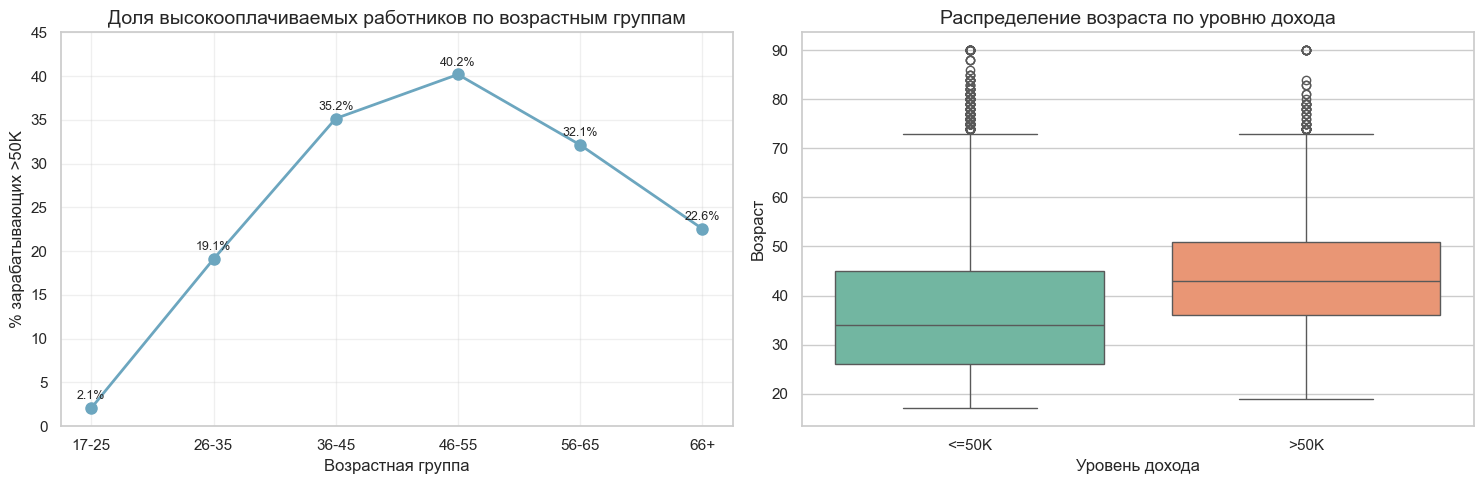

In [24]:
# визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# средний доход по возрастным группам
age_salary = adultdf.groupby('age_group')['salary'].apply(lambda x: (x == '>50K').mean() * 100).reset_index()
age_salary.columns = ['age_group', 'percent_high_salary']

axes[0].plot(age_salary['age_group'], age_salary['percent_high_salary'], marker='o', linewidth=2, markersize=8, color='#6CA6BF')
axes[0].set_title('Доля высокооплачиваемых работников по возрастным группам', fontsize=14)
axes[0].set_xlabel('Возрастная группа')
axes[0].set_ylabel('% зарабатывающих >50K')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 45)
for i, v in enumerate(age_salary['percent_high_salary']):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

# boxplot возраста по уровню дохода
sns.boxplot(data=adultdf, x='salary', y='age', ax=axes[1], palette='Set2')
axes[1].set_title('Распределение возраста по уровню дохода', fontsize=14)
axes[1].set_xlabel('Уровень дохода')
axes[1].set_ylabel('Возраст')

plt.tight_layout()
plt.show()

Исследование влияния возраста на уровень дохода наглядно подтверждает, что жизненный цикл человека неразрывно связан с его экономическими достижениями. Графики и статистические срезы демонстрируют, что медианный возраст группы с высоким доходом существенно сдвинут вправо по сравнению с группой низких доходов. Доля высокооплачиваемых работников неуклонно растет от младшей возрастной группы (17–25 лет) к группе зрелых профессионалов (36–55 лет), где достигает своих максимальных значений. Это отражает классическую экономическую теорию человеческого капитала: с каждым годом работы накапливаются специфические навыки, опыт и репутация, которые рынок труда щедро вознаграждает.

Однако после достижения 55-60 лет кривая вероятности высокого дохода начинает снижаться. Это может быть связано с выходом части обеспеченных людей на пенсию, переходом на менее оплачиваемые, но более спокойные должности, либо с возрастной дискриминацией на рынке труда, которая затрудняет удержание высоких позиций. Таким образом, возраст формирует своеобразную «дугу успеха», где пик финансового благополучия приходится на период максимальной профессиональной зрелости, а молодость и глубокая старость оказываются зонами повышенного финансового риска.

<a id=4.2.></a>
### 4.2. Тип занятости и уровень образования

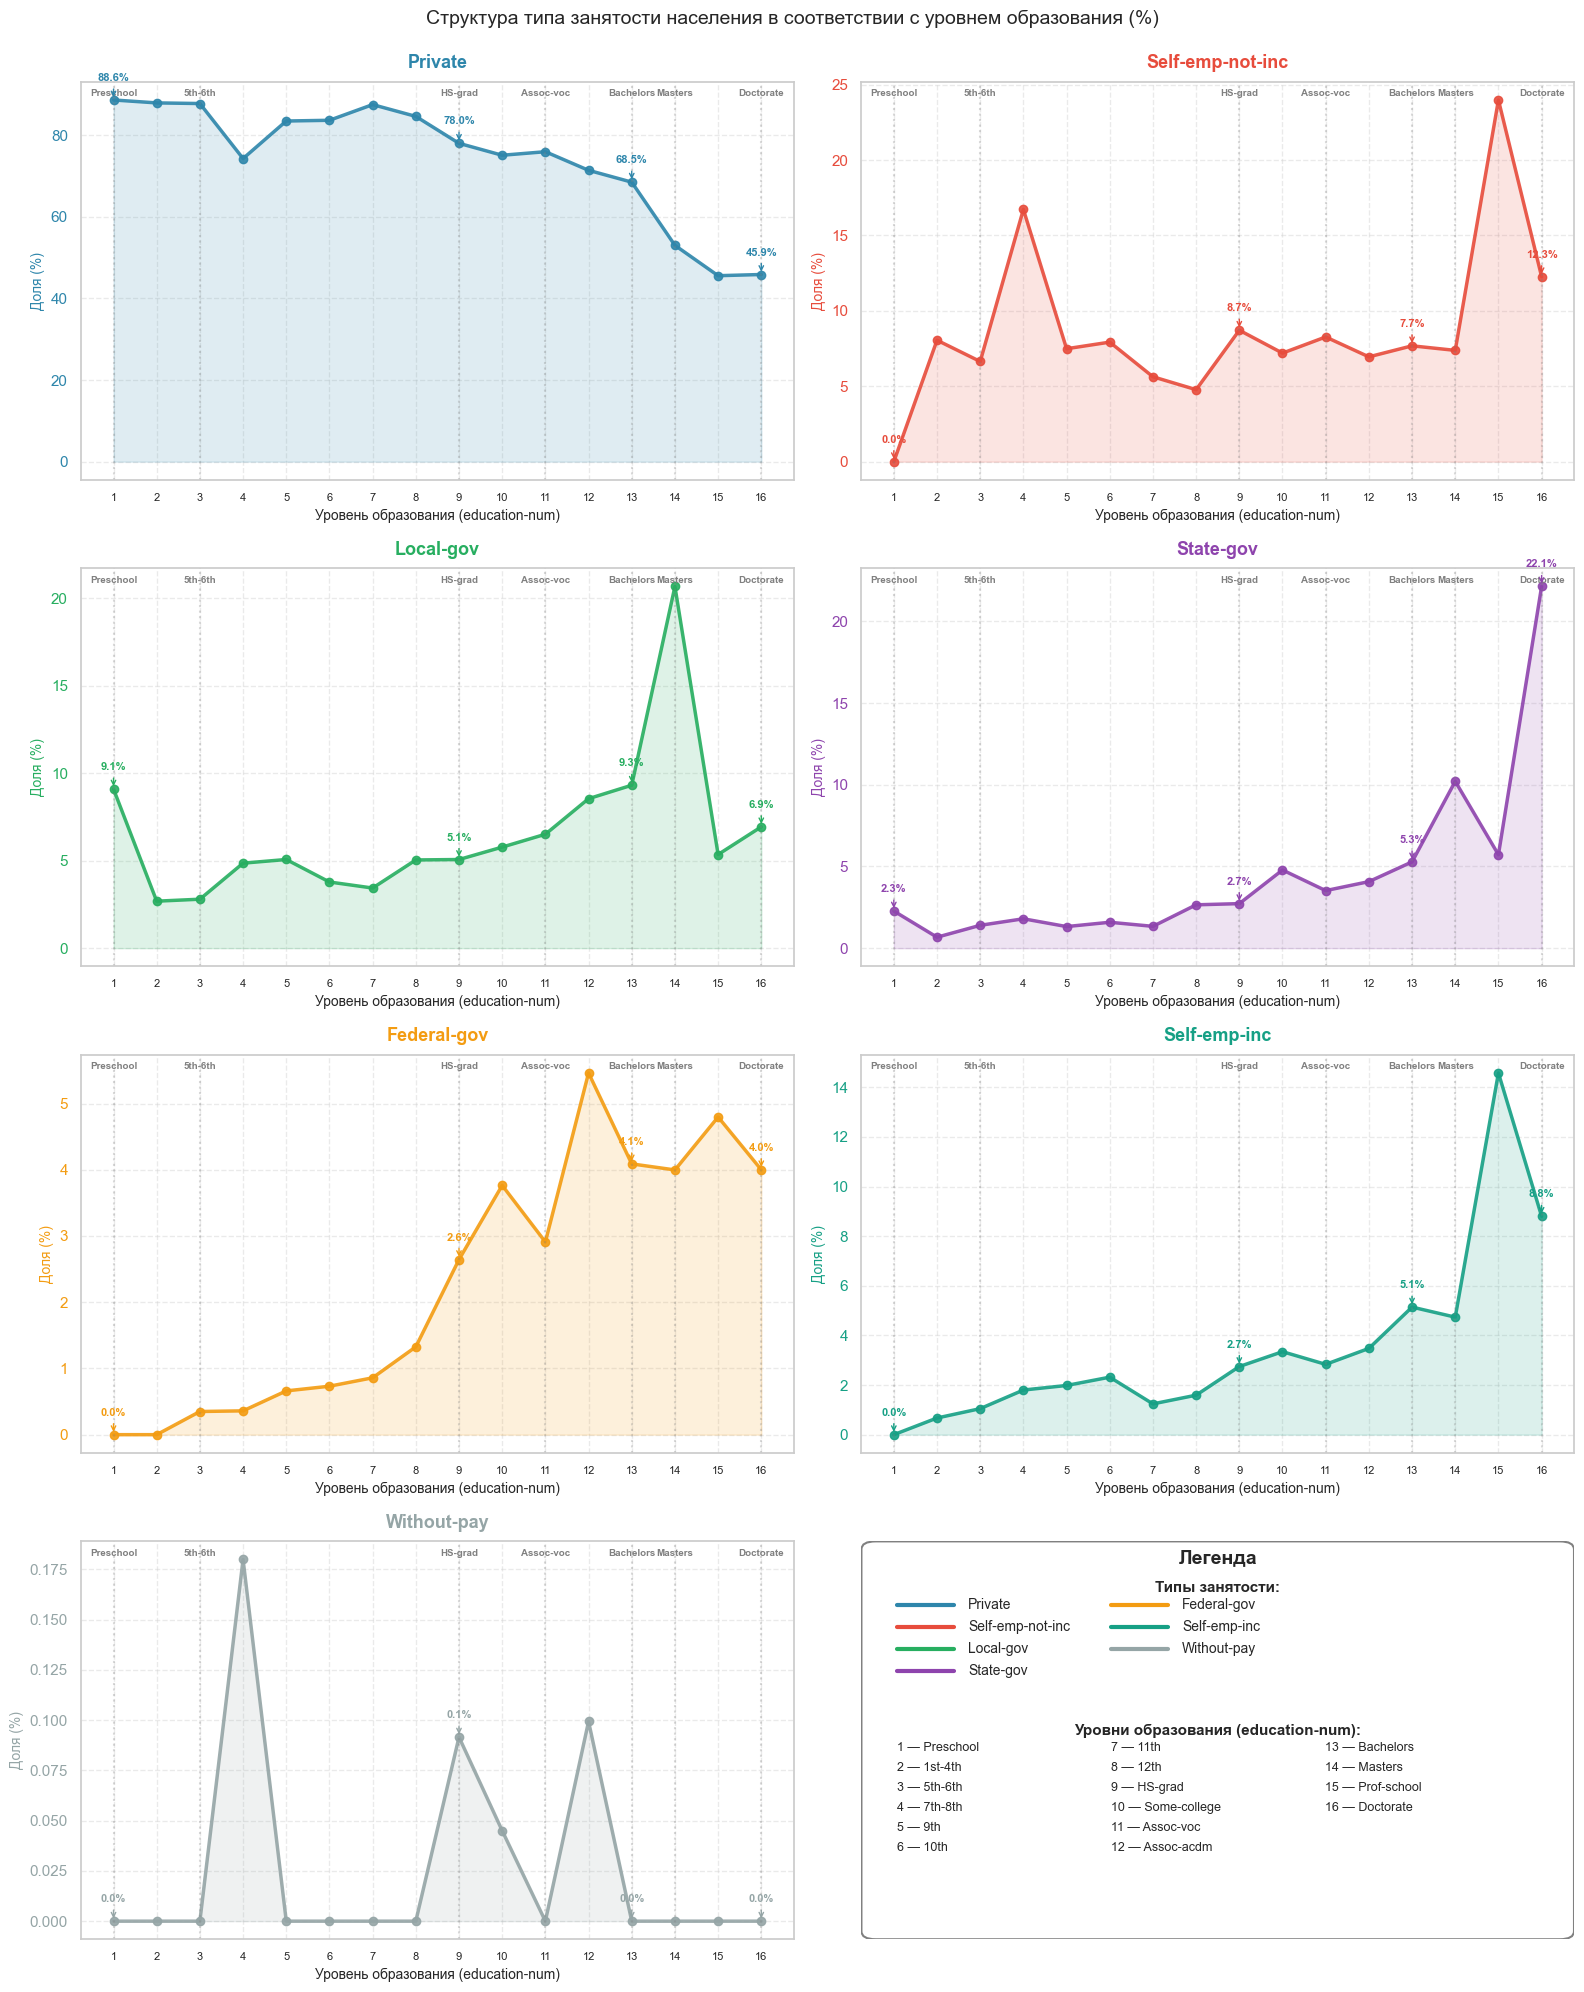

In [25]:
# группируем данные и считаем проценты внутри каждого уровня образования
edu_workclass = pd.crosstab(adultdf['education-num'], adultdf['workclass'], normalize='index') * 100

# типы занятости и их цвета
workclass_colors = {
    'Private': '#2E86AB',
    'Self-emp-not-inc': '#E74C3C',
    'Local-gov': '#27AE60',
    'State-gov': '#8E44AD',
    'Federal-gov': '#F39C12',
    'Self-emp-inc': '#16A085',
    'Without-pay': '#95A5A6'
}

# ключевые уровни образования для аннотаций
key_edu_levels = {
    1: 'Preschool',
    9: 'HS-grad',
    13: 'Bachelors',
    16: 'Doctorate'
}

# все уровни образования для подписей сверху
all_edu_labels = {
    1: 'Preschool',
    3: '5th-6th',
    9: 'HS-grad',
    11: 'Assoc-voc',
    13: 'Bachelors',
    14: 'Masters',
    16: 'Doctorate'
}

# создаём фигуру 4x2 (4 строки, 2 столбца)
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()  # превращаем в одномерный массив для удобства

# cтроим 7 графиков по типам занятости
for idx, (workclass, color) in enumerate(workclass_colors.items()):
    ax = axes[idx]
    
    # данные для текущего типа занятости
    data = edu_workclass[workclass]
    
    # линия с маркерами
    ax.plot(data.index, data.values, marker='o', linewidth=2.5, markersize=6, color=color, alpha=0.9)
    
    # заполнение под линией
    ax.fill_between(data.index, data.values, alpha=0.15, color=color)
    
    # заголовок
    ax.set_title(workclass, fontsize=13, fontweight='bold', pad=10, color=color)
    
    # оси
    ax.set_xlabel('Уровень образования (education-num)', fontsize=10)
    ax.set_ylabel('Доля (%)', fontsize=10, color=color)
    ax.tick_params(axis='y', labelcolor=color)
    
    # сетка
    ax.grid(True, linestyle='--', alpha=0.4)
    
    # вертикальные пунктирные линии и подписи ключевых уровней образования
    for edu_num, label in all_edu_labels.items():
        ax.axvline(edu_num, color='gray', linestyle=':', alpha=0.3)
        ax.text(edu_num, ax.get_ylim()[1] * 0.98, label, ha='center', va='top', fontsize=7, color='gray', fontweight='bold')
    
    # аннотации ключевых точек
    for edu_num in key_edu_levels.keys():
        if edu_num in data.index:
            val = data.loc[edu_num]
            ax.annotate(f'{val:.1f}%', xy=(edu_num, val), xytext=(edu_num, val + ax.get_ylim()[1] * 0.05), ha='center', fontsize=8, color=color, fontweight='bold', arrowprops=dict(arrowstyle='->', color=color, lw=1))
    
    # ticks
    ax.set_xticks(range(1, 17))
    ax.set_xticklabels(range(1, 17), fontsize=8)

# легенда и расшифровка образования
ax_legend = axes[7]
ax_legend.axis('off')  # скрываем оси

# заголовок блока легенды
ax_legend.text(0.5, 0.98, 'Легенда', ha='center', va='top', fontsize=14, fontweight='bold', transform=ax_legend.transAxes)

# блок "Типы занятости"
y_pos_title = 0.90
ax_legend.text(0.5, y_pos_title, 'Типы занятости:', ha='center', va='top', fontsize=11, fontweight='bold', transform=ax_legend.transAxes)

# цветовые обозначения типов занятости (в 2 столбца)
# начинаем с большего отступа от подзаголовка
y_pos_start = 0.84
workclass_items = list(workclass_colors.items())

# первая колонка типов занятости (4 элемента)
# увеличенный интервал между элементами: 0.055
for i, (workclass, color) in enumerate(workclass_items[:4]):
    y_pos = y_pos_start - i * 0.055
    ax_legend.plot([0.05, 0.13], [y_pos, y_pos], color=color, linewidth=3, transform=ax_legend.transAxes)
    ax_legend.text(0.15, y_pos, workclass, va='center', fontsize=10, transform=ax_legend.transAxes)

# вторая колонка типов занятости (3 элемента)
for i, (workclass, color) in enumerate(workclass_items[4:]):
    y_pos = y_pos_start - i * 0.055
    ax_legend.plot([0.35, 0.43], [y_pos, y_pos], color=color, linewidth=3, transform=ax_legend.transAxes)
    ax_legend.text(0.45, y_pos, workclass, va='center', fontsize=10, transform=ax_legend.transAxes)

# блок "Уровни образования"
# рассчитываем позицию: после последнего элемента типов занятости + большой отступ
y_pos_edu_title = y_pos_start - 4 * 0.055 - 0.08  # дополнительный отступ 0.08
ax_legend.text(0.5, y_pos_edu_title, 'Уровни образования (education-num):', ha='center', va='top', fontsize=11, fontweight='bold', transform=ax_legend.transAxes)

# получаем соответствие образования
edu_mapping = adultdf[['education', 'education-num']].drop_duplicates().sort_values('education-num')
edu_list = [(int(row['education-num']), row['education']) for _, row in edu_mapping.iterrows()]

# разбиваем на 3 столбца
n_items = len(edu_list)
items_per_col = (n_items + 2) // 3  # округляем вверх

# начинаем список категории "образование" с отступом от подзаголовка
y_pos_edu_start = y_pos_edu_title - 0.06  # отступ 0.06 от подзаголовка

# первый столбец (уровни 1-6)
for i, (edu_num, edu_name) in enumerate(edu_list[:items_per_col]):
    y_pos_item = y_pos_edu_start - i * 0.05
    ax_legend.text(0.05, y_pos_item, f"{edu_num} — {edu_name}", va='center', fontsize=9, transform=ax_legend.transAxes)

# второй столбец (уровни 7-12)
for i, (edu_num, edu_name) in enumerate(edu_list[items_per_col:items_per_col*2]):
    y_pos_item = y_pos_edu_start - i * 0.05
    ax_legend.text(0.35, y_pos_item, f"{edu_num} — {edu_name}", va='center', fontsize=9, transform=ax_legend.transAxes)

# третий столбец (уровни 13-16)
for i, (edu_num, edu_name) in enumerate(edu_list[items_per_col*2:]):
    y_pos_item = y_pos_edu_start - i * 0.05
    ax_legend.text(0.65, y_pos_item, f"{edu_num} — {edu_name}", va='center', fontsize=9, transform=ax_legend.transAxes)

# рамка вокруг блока легенды
from matplotlib.patches import FancyBboxPatch
rect = FancyBboxPatch((0.02, 0.02), 0.96, 0.96, boxstyle="round,pad=0.02", edgecolor='gray', facecolor='white', linewidth=1.5, transform=ax_legend.transAxes)
ax_legend.add_patch(rect)

# общий заголовок
fig.suptitle('Структура типа занятости населения в соответствии с уровнем образования (%)', fontsize=14, y=0.995)

plt.tight_layout()
plt.show()

Образовательная вертикаль выступает главным механизмом социальной стратификации и социальным лифтом, что отчетливо видно при пересечении уровня образования и типа занятости. Люди с высшим образованием (бакалавриат, магистратура, докторантура) имеют непропорционально высокую долю в таких секторах, как государственное управление, а также в сфере самозанятости с инкорпорированным бизнесом. Высшее образование открывает двери в престижные профессии и предоставляет ресурсы для создания собственного дела, обеспечивая финансовую независимость.

В то же время респонденты без высшего образования, ограниченные школьным аттестатом или неполным средним образованием, статистически «заперты» в традиционном частном секторе или в категориях неоплачиваемого труда. Для них частный сектор становится не путем к успеху, а вынужденной мерой, поскольку он концентрирует в себе массовые, низкооплачиваемые позиции, не требующие высокой квалификации. Разрыв в возможностях между этими группами колоссален: образование не просто меняет тип занятости, оно кардинально меняет саму траекторию жизни, переводя человека из категории наемного работника с низкой добавленной стоимостью в категорию специалистов, принимающих решения или владеющих капиталом.

<a id=4.3.></a>
### 4.3. Уровень дохода по профессиям

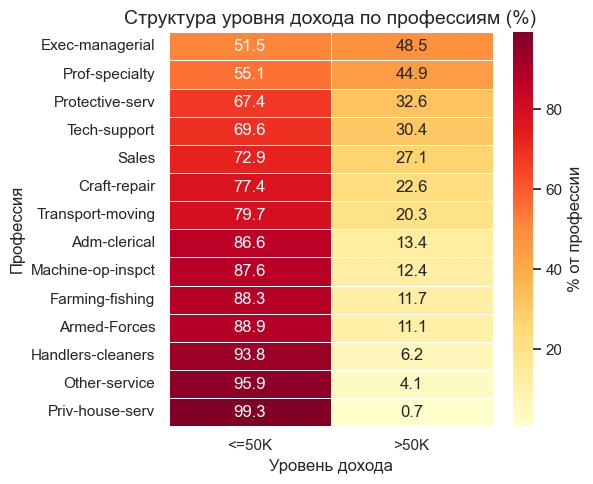

In [26]:
# визуализация: распределение дохода по профессиям в долях (тепловая карта)
plt.figure(figsize=(6, 5))

# считаем доли по строкам (normalize='index') - процент <=50K и >50K внутри каждой профессии
occupation_salary_pct = pd.crosstab(adultdf['occupation'], adultdf['salary'], normalize='index') * 100

# сортируем по убыванию доли высокооплачиваемых (>50K), чтобы "успешные" профессии были вверху
occupation_salary_pct = occupation_salary_pct.loc[occupation_salary_pct['>50K'].sort_values(ascending=False).index]

# строим тепловую карту
sns.heatmap(occupation_salary_pct, cmap='YlOrRd', annot=True, fmt='.1f', linewidths=0.5, cbar_kws={'label': '% от профессии'})

plt.title('Структура уровня дохода по профессиям (%)', fontsize=14)
plt.xlabel('Уровень дохода', fontsize=12)
plt.ylabel('Профессия', fontsize=12)
plt.tight_layout()
plt.show()

Анализ распределения профессий в разрезе уровня дохода фиксирует жесткую профессиональную сегрегацию и существование «элитных» и «периферийных» сфер. Руководящие должности, узкопрофильные специалисты (врачи, юристы, инженеры), а также сфера продаж концентрируют в себе основной объем высоких доходов. Именно в этих профессиях доля зарабатывающих свыше 50 тысяч долларов достигает максимальных значений, что отражает высокую стоимость управленческих, интеллектуальных и коммуникативных навыков в экономике знаний.

Противоположный полюс занимают сферы обслуживания, клининга, сельского хозяйства, транспортных услуг и ручного труда. В этих профессиях процент высокооплачиваемых работников стремится к нулю, что указывает на системную бедность, заложенную в самой природе этих занятий. Они требуют тяжелого физического труда, часто не предполагают карьерного роста и легко заменяемы, что не позволяет работникам претендовать на высокую долю в прибавочной стоимости. Таким образом, выбор профессии является одним из самых сильных предикторов финансового будущего, жестко определяющим потолок доходов индивида.

<a id=5></a>
## Шаг 5. Гендерное неравенство

<a id=5.1.></a>
### 5.1. Гендерный анализ доходов

Свяжем сразу три измерения: пол × страна × доход. Это даст мощный социологический вывод о роли культурных норм.

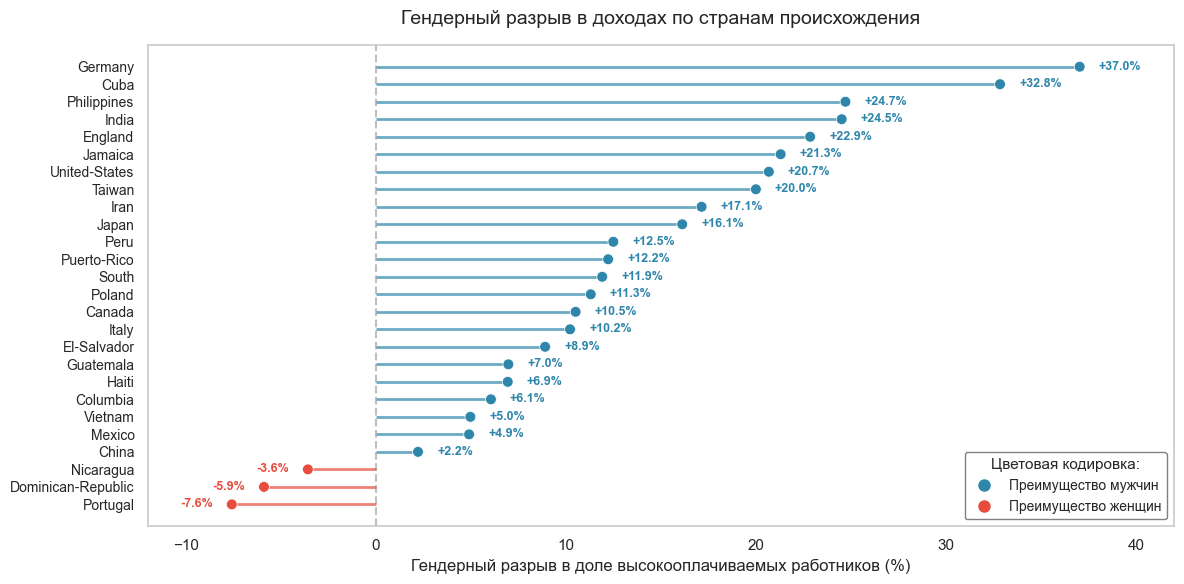

In [27]:
# визуализация
# фильтруем только страны с достаточным количеством респондентов
country_counts = adultdf['native-country'].value_counts()
top_countries = country_counts[country_counts >= 30].index.tolist()
df_filtered = adultdf[adultdf['native-country'].isin(top_countries)]

# считаем долю >50K для мужчин и женщин по каждой стране
gender_country_salary = df_filtered.groupby(['native-country', 'sex'])['salary'].apply(lambda x: (x == '>50K').mean() * 100).unstack()

# рассчитываем гендерный разрыв (мужчины - женщины)
gender_country_salary['gap'] = gender_country_salary['Male'] - gender_country_salary['Female']

# сортируем по величине разрыва
gender_country_salary = gender_country_salary.sort_values('gap', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))

# определяем цвета: синий для положительного разрыва (преимущество мужчин),
# красный для отрицательного (преимущество женщин)
colors = ['#2E86AB' if gap >= 0 else '#E74C3C' for gap in gender_country_salary['gap']]

# лоллипоп-график
y_pos = range(len(gender_country_salary))
ax.hlines(y=y_pos, xmin=0, xmax=gender_country_salary['gap'], color=colors, alpha=0.7, linewidth=2)
ax.scatter(gender_country_salary['gap'], y_pos, color=colors, s=60, zorder=3, edgecolor='white', linewidth=0.5)

# вертикальная линия на нуле
ax.axvline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)

# оформление
ax.set_yticks(y_pos)
ax.set_yticklabels(gender_country_salary.index, fontsize=10)
ax.set_xlabel('Гендерный разрыв в доле высокооплачиваемых работников (%)', fontsize=12)
ax.set_title('Гендерный разрыв в доходах по странам происхождения', fontsize=14, pad=15)

# подписи значений с цветовым кодированием
for i, (country, gap) in enumerate(gender_country_salary['gap'].items()):
    offset = 1 if gap >= 0 else -1
    ha = 'left' if gap >= 0 else 'right'
    color = '#2E86AB' if gap >= 0 else '#E74C3C'
    ax.text(gap + offset, i, f'{gap:+.1f}%', va='center', ha=ha, fontsize=9, fontweight='bold', color=color)

ax.set_xlim(-12, 42)
ax.grid(False)

# легенда
# кастомные подписи для легенды
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2E86AB', markersize=10, label='Преимущество мужчин'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E74C3C', markersize=10, label='Преимущество женщин')]

legend = ax.legend(handles=legend_handles, loc='lower right', fontsize=10, title='Цветовая кодировка:', title_fontsize=11, frameon=True, facecolor='white', edgecolor='gray', framealpha=1)
legend.set_zorder(100)  # поднимаем легенду над всеми элементами

plt.tight_layout()
plt.show()

Гендерный анализ доходов обнажает проблему глобального и системного неравенства, которое пронизывает все слои общества. Сопоставление доли высокооплачиваемых мужчин и женщин по странам происхождения показывает, что гендерный разрыв присутствует практически во всех культурных и географических средах. Мужчины статистически значительно чаще преодолевают порог высокого дохода, причем этот перевес сохраняется даже в странах с традиционно более прогрессивными взглядами на роль женщин в обществе.

Этот феномен не может быть объяснен исключительно различиями в выборе профессий или уровне образования, так как разрыв сохраняется при контроле этих факторов. Он указывает на наличие глубинных структурных барьеров, таких как невидимый потолок, неосознанная предвзятость работодателей при найме и продвижении, а также неравномерное распределение семейных обязанностей, которое вынуждает женщин чаще прерывать карьеру или работать в режиме частичной занятости. Гендерный разрыв в доходах оказывается универсальной чертой общества конца XX века, доказывающей, что принадлежность к определенному полу сама по себе является фактором, влияющим на экономические перспективы.

<a id=5.2.></a>
### 5.2. Гендерное неравенство в профессиях и уровню дохода

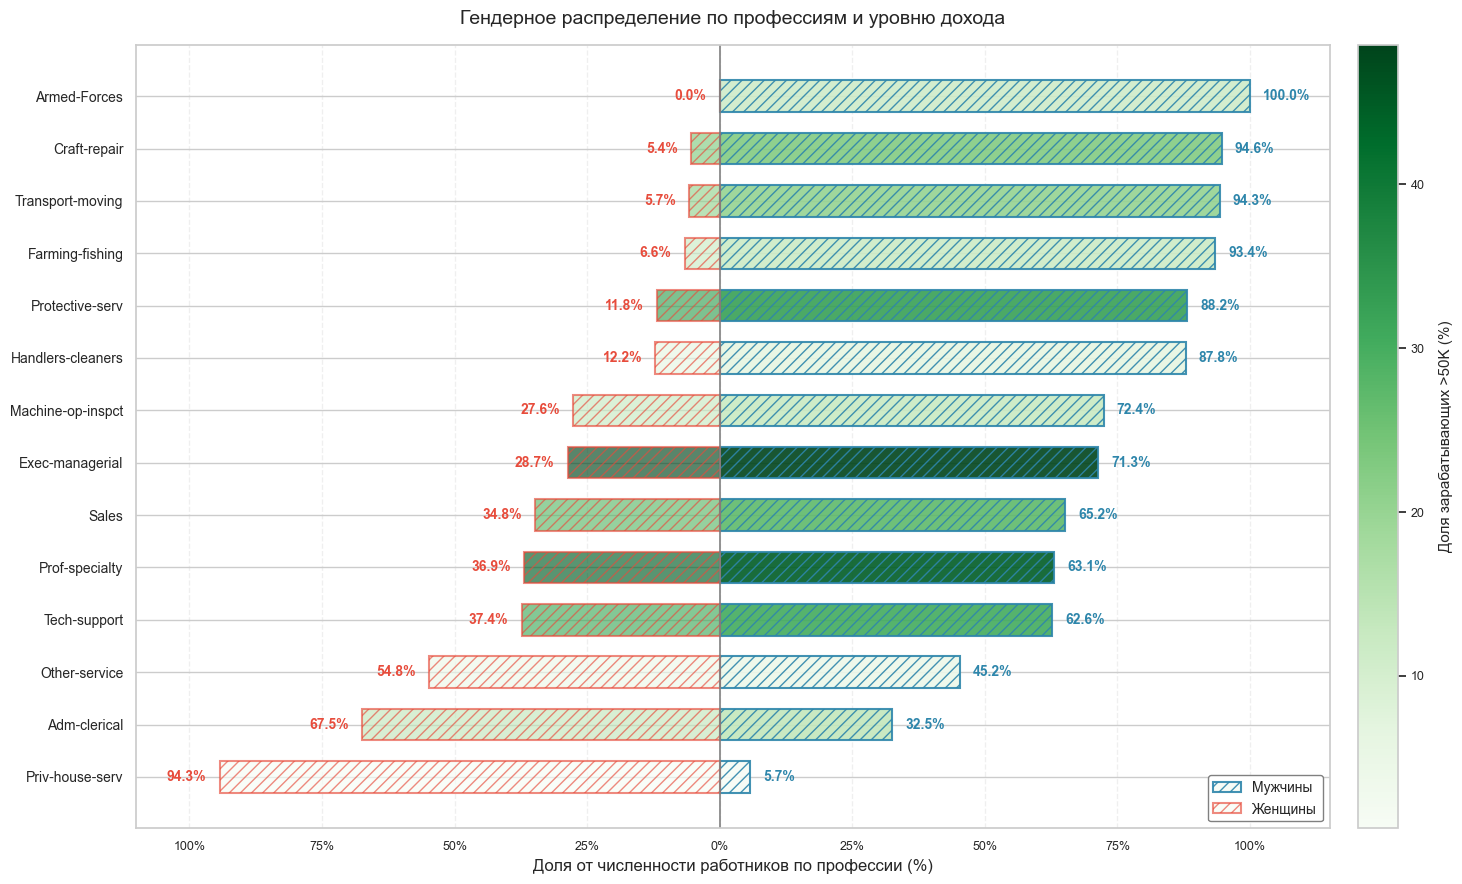

In [28]:
# считаем доли и уровень дохода
occupation_sex = pd.crosstab(adultdf['occupation'], adultdf['sex'], normalize='index') * 100
occupation_salary_pct = adultdf.groupby('occupation')['salary'].apply(lambda x: (x == '>50K').mean() * 100)
occupation_data = occupation_sex.copy()
occupation_data['high_salary_pct'] = occupation_salary_pct
occupation_data = occupation_data.sort_values('Male', ascending=True)

# нормализация для colormap
norm = mcolors.Normalize(vmin=occupation_data['high_salary_pct'].min(), vmax=occupation_data['high_salary_pct'].max())

# палитра
cmap = plt.cm.Greens

# цвета для столбцов
income_colors = [cmap(norm(val)) for val in occupation_data['high_salary_pct']]

# создаём фигуру
fig, ax = plt.subplots(figsize=(16, 9))
y_pos = range(len(occupation_data))

# мужские столбцы
ax.barh(y_pos, occupation_data['Male'], color=income_colors, alpha=0.9, label='Мужчины', height=0.6, edgecolor='#2E86AB', linewidth=1.5, hatch='///')

# женские столбцы
ax.barh(y_pos, -occupation_data['Female'], color=income_colors, alpha=0.65, label='Женщины', height=0.6, edgecolor='#E74C3C', linewidth=1.5, hatch='///')

# вертикальная линия в центре
ax.axvline(0, color='gray', linestyle='-', linewidth=1.2)

# подписи значений на концах столбцов
offset = 2.5  # отступ в процентах
for i, (occupation, row) in enumerate(occupation_data.iterrows()):
    # мужчины справа — синий цвет
    ax.text(row['Male'] + offset, i, f"{row['Male']:.1f}%", va='center', ha='left', fontsize=10, color='#2E86AB', fontweight='bold')
    # женщины слева — красный цвет
    ax.text(-row['Female'] - offset, i, f"{row['Female']:.1f}%", va='center', ha='right', fontsize=10, color='#E74C3C', fontweight='bold')

# оформление
ax.set_yticks(y_pos)
ax.set_yticklabels(occupation_data.index, fontsize=10)

# УВЕЛИЧИЛИ ДИАПАЗОН ОСИ X с запасом в обе стороны
ax.set_xlim(-110, 115)  # было (-100, 100), стало (-110, 110)

# обновили ticks под новый диапазон
ticks = [-100, -75, -50, -25, 0, 25, 50, 75, 100]
ax.set_xticks(ticks)
ax.set_xticklabels([f'{abs(t)}%' for t in ticks], fontsize=9)

ax.set_xlabel('Доля от численности работников по профессии (%)', fontsize=12)
ax.set_title('Гендерное распределение по профессиям и уровню дохода', fontsize=14, pad=15)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# colorbar — шкала дохода
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Доля зарабатывающих >50K (%)', fontsize=11, labelpad=10)
cbar.ax.tick_params(labelsize=9)

# легенда
legend = ax.legend(loc='lower right', fontsize=10, facecolor='white', edgecolor='gray', framealpha=1)
legend.set_zorder(100)

plt.tight_layout()
plt.show()

In [29]:
# какие профессии дают >50% успеха для мужчин, но <30% для женщин?
# агрегация
combo_stats = adultdf.groupby(['education', 'occupation', 'sex']).agg(count=('salary', 'size'), success_rate=('salary', lambda x: (x == '>50K').mean() * 100)).reset_index()

# фильтрация
top_combos = combo_stats[(combo_stats['success_rate'] > 40) & (combo_stats['count'] > 50)].copy().sort_values('success_rate', ascending=False).head(20)

# сначала фильтруем только успешные стратегии
successful = combo_stats[combo_stats['success_rate'] > 40].copy()

# создаём pivot-таблицу: строки = (education, occupation), столбцы = sex
pivot = successful.pivot_table(index=['education', 'occupation'], columns='sex', values='success_rate')

# считаем разрыв только там, где есть данные для обоих полов
pivot['gap'] = pivot['Male'] - pivot['Female']

# сортируем по убыванию разрыва
gender_gap = pivot.sort_values('gap', ascending=False).reset_index()

print("Профессии с максимальным гендерным разрывом в успешных стратегиях:")
print("(где мужчины зарабатывают >50K значительно чаще женщин)")
print("="*80)
print(gender_gap[['education', 'occupation', 'Male', 'Female', 'gap']].head(10).to_string(index=False))
print("="*80)

Профессии с максимальным гендерным разрывом в успешных стратегиях:
(где мужчины зарабатывают >50K значительно чаще женщин)
  education      occupation  Male  Female   gap
Prof-school  Prof-specialty  82.8    47.1  35.7
    Masters Exec-managerial  82.1    47.6  34.5
  Doctorate  Prof-specialty  78.1    53.8  24.2
Prof-school Exec-managerial  75.0    75.0   0.0
  Doctorate Exec-managerial  90.5    91.7  -1.2
Prof-school           Sales  61.5    75.0 -13.5
  Doctorate           Sales  57.1   100.0 -42.9
       10th  Prof-specialty  60.0     NaN   NaN
       10th    Tech-support  50.0     NaN   NaN
       12th    Tech-support   NaN   100.0   NaN


Детальный анализ гендерного распределения по профессиям доказывает наличие горизонтальной и вертикальной сегрегации на рынке труда. Мужчины доминируют в высокооплачиваемых руководящих и технических сферах, где концентрация высокого дохода максимальна. Женщины же статистически сконцентрированы в административных ролях, сфере обслуживания и образования, которые, несмотря на свою социальную значимость, исторически оплачиваются значительно ниже.

Более того, даже внутри одних и тех же успешных профессиональных стратегий, требующих высокого уровня образования, мужчины сохраняют преимущество в шансах на высокий доход. Анализ показывает, что существуют профессии и уровни образования, которые гарантируют успех более чем половине мужчин, но дают такой же шанс менее чем трети женщин. Это разрушает иллюзию меритократии и подтверждает, что карьерные барьеры не позволяют женщинам в полной мере конвертировать свои профессиональные навыки и квалификацию в равный с мужчинами финансовый результат.

<a id=5.3.></a>
### 5.3. Гендерное неравенство в уровне дохода и контексте образования

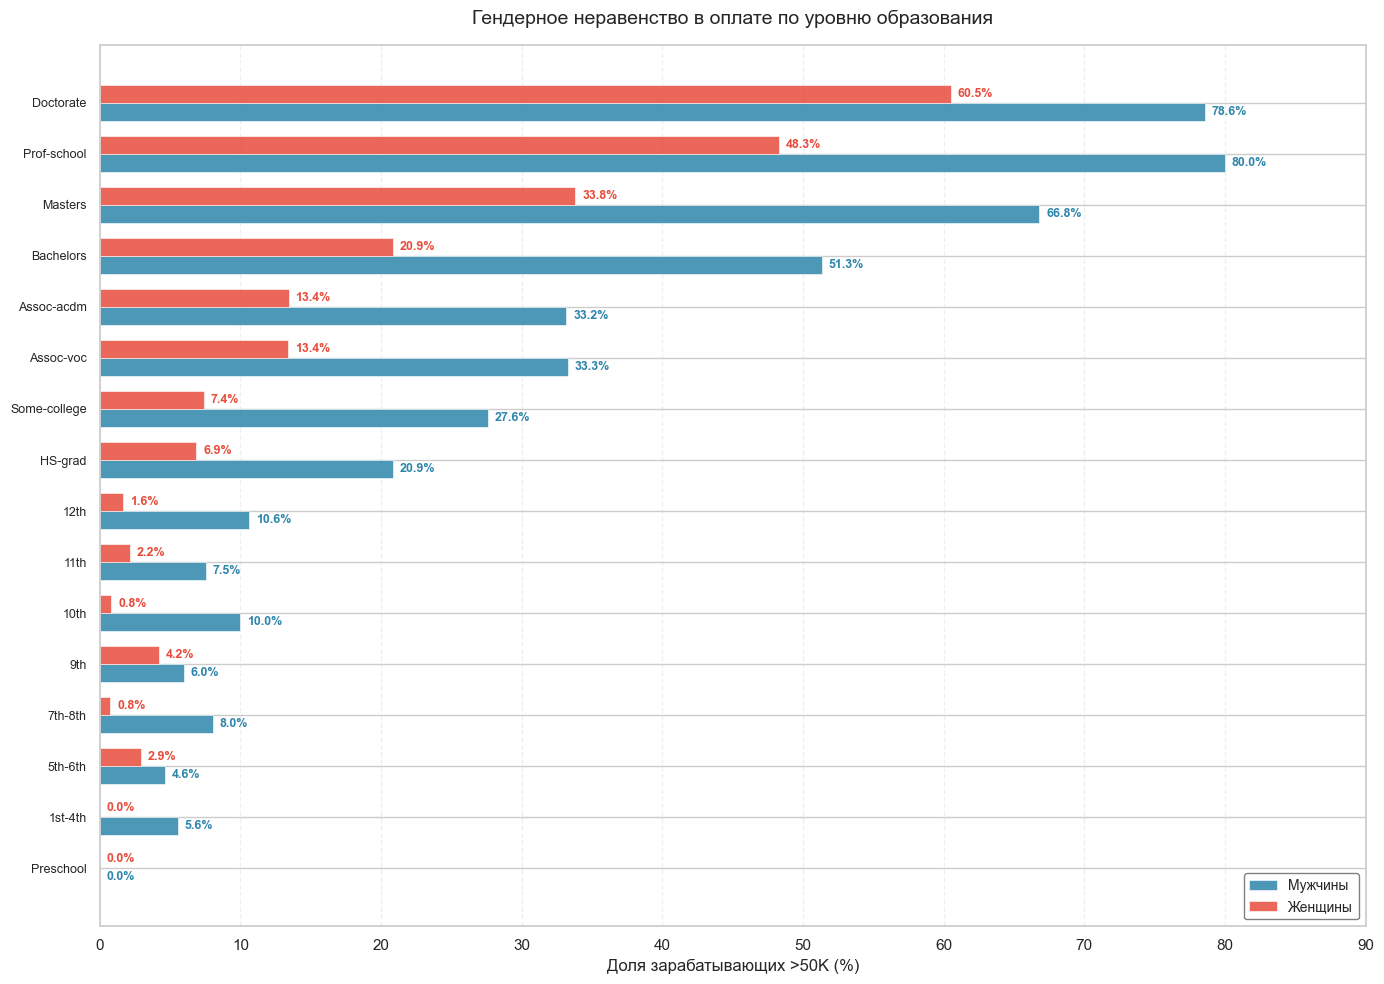

In [30]:
# визуализация: гендерное неравенство в оплате по уровню образования (вертикальная шкала)

# группируем данные по education-num и sex, считаем долю >50K
edu_num_sex_salary = adultdf.groupby(['education-num', 'sex'])['salary'].apply(lambda x: (x == '>50K').mean() * 100).unstack()

# добавляем названия уровней образования для подписей
edu_mapping = adultdf[['education', 'education-num']].drop_duplicates().sort_values('education-num')
edu_labels_dict = dict(zip(edu_mapping['education-num'], edu_mapping['education']))

# создаём фигуру
fig, ax = plt.subplots(figsize=(14, 10))

# позиции по оси Y (образование)
y_pos = range(len(edu_num_sex_salary))

# ширина столбцов
bar_width = 0.35

# строим сдвоенные столбцы: мужчины (синий), женщины (красный)
bars_male = ax.barh([i - bar_width/2 for i in y_pos], edu_num_sex_salary['Male'], height=bar_width, label='Мужчины', color='#2E86AB', alpha=0.85,edgecolor='white',linewidth=0.5)

bars_female = ax.barh([i + bar_width/2 for i in y_pos], edu_num_sex_salary['Female'], height=bar_width, label='Женщины', color='#E74C3C', alpha=0.85, edgecolor='white', linewidth=0.5)

# подписи уровней образования по оси Y
ax.set_yticks(y_pos)
ax.set_yticklabels([edu_labels_dict.get(i, str(i)) for i in edu_num_sex_salary.index], fontsize=9)

# подписи значений
for i, (edu_num, row) in enumerate(edu_num_sex_salary.iterrows()):
    # мужчины — синий текст по центру мужского столбца (позиция i - bar_width/2)
    ax.text(row['Male'] + 0.5, i - bar_width/2, f'{row["Male"]:.1f}%', va='center', ha='left', fontsize=9, color='#2E86AB', fontweight='bold')
    
    # женщины — красный текст по центру женского столбца (позиция i + bar_width/2)
    ax.text(row['Female'] + 0.5, i + bar_width/2, f'{row["Female"]:.1f}%', va='center', ha='left', fontsize=9, color='#E74C3C', fontweight='bold')

# оформление
ax.set_xlabel('Доля зарабатывающих >50K (%)', fontsize=12)
ax.set_title('Гендерное неравенство в оплате по уровню образования', fontsize=14, pad=15)

# сетка
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# расширяем xlim для подписей
max_val = max(edu_num_sex_salary['Male'].max(), edu_num_sex_salary['Female'].max())
ax.set_xlim(0, max_val + 10)

# легенда
legend = ax.legend(loc='lower right', fontsize=10, facecolor='white', edgecolor='gray', framealpha=1)
legend.set_zorder(100)

plt.tight_layout()
plt.show()

Анализ гендерного неравенства в оплате труда в разрезе уровней образования окончательно разрушает миф о том, что диплом нивелирует дискриминацию. Наглядная визуализация показывает, что на каждом без исключения уровне образования — от начальной школы до докторской степени — процент мужчин с высоким доходом стабильно превышает аналогичный показатель у женщин. Образование, безусловно, повышает шансы на успех для обоих полов, но не меняет самого факта неравенства.

Примечательно, что абсолютный разрыв в доходах часто увеличивается по мере роста квалификации. Если на уровне школьного аттестата разница может быть не столь катастрофической, то среди обладателей докторских степеней или профессиональных медицинских квалификаций мужчины отрываются от женщин на десятки процентных пунктов. Это свидетельствует о том, что с продвижением по карьерной лестнице и ростом ответственности системные барьеры для женщин лишь усиливаются, а высшее образование не является панацеей от гендерной асимметрии в распределении экономических благ.

<a id=6></a>
## Шаг 6. Расовое неравенство и сегрегация

<a id=6.1.></a>
### 6.1. Расовое неравенство в доходах

Такой график позволяет сразу увидеть, какой образовательный «потолок» характерен для каждой расовой группы. 

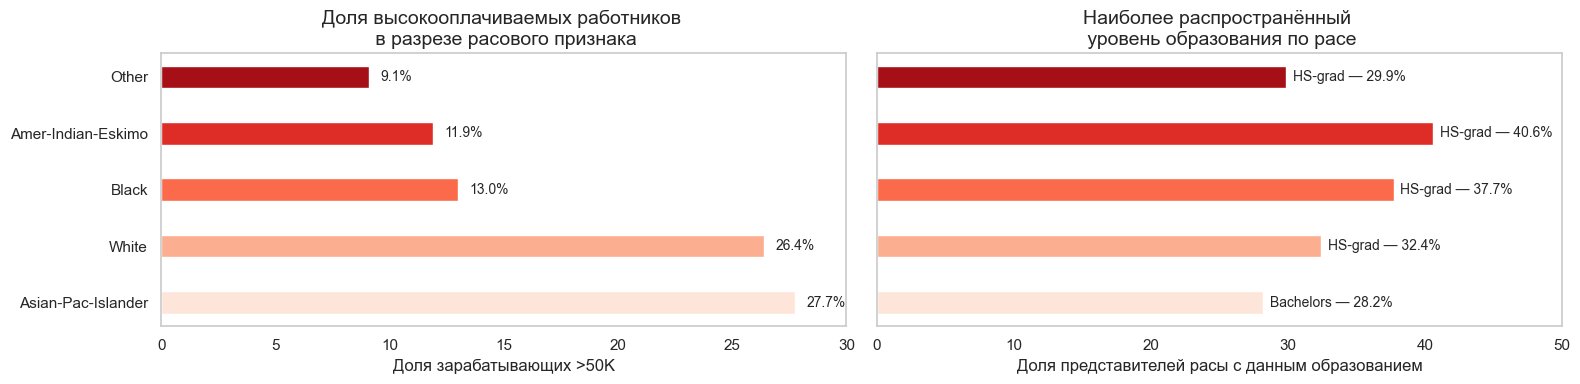

In [31]:
# визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

# график 1: доля высокооплачиваемых работников по расе
race_salary = adultdf.groupby('race')['salary'].apply(lambda x: (x == '>50K').mean() * 100).reset_index()
race_salary = race_salary.sort_values('salary', ascending=False)

# монохромная палитра
colors_orange = ['#FEE5D9', '#FCAE91', '#FB6A4A', '#DE2D26', '#A50F15']

axes[0].set_xlim(0, 30)
axes[0].barh(race_salary['race'], race_salary['salary'], color=colors_orange, height=0.4)
axes[0].set_title('Доля высокооплачиваемых работников \n в разрезе расового признака', fontsize=14)
axes[0].set_xlabel('Доля зарабатывающих >50K', fontsize=12)

for i, v in enumerate(race_salary['salary']):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

# убираем сетку
axes[0].grid(False)

# график 2: самое распространённое образование по расе
most_common_edu = adultdf.groupby('race')['education'].agg(top_edu=lambda x: x.value_counts().index[0], top_edu_pct=lambda x: x.value_counts().iloc[0] / len(x) * 100).reset_index()

race_order = race_salary['race'].tolist()
most_common_edu['race'] = pd.Categorical(most_common_edu['race'], categories=race_order, ordered=True)
most_common_edu = most_common_edu.sort_values('race')

axes[1].set_xlim(0, 50)
axes[1].barh(most_common_edu['race'], most_common_edu['top_edu_pct'], color=colors_orange, height=0.4)
axes[1].set_title('Наиболее распространённый \n уровень образования по расе', fontsize=14)
axes[1].set_xlabel('Доля представителей расы с данным образованием', fontsize=12)

for i, (edu, pct) in enumerate(zip(most_common_edu['top_edu'],
                                   most_common_edu['top_edu_pct'])):
    axes[1].text(pct + 0.5, i, f'{edu} — {pct:.1f}%', va='center', fontsize=10)

axes[1].grid(False)
axes[1].tick_params(labelleft=False)  # убираем дублирующиеся подписи по оси Y на втором графике

plt.tight_layout()
plt.show()

Исследование расового неравенства в доходах показывает, что экономическое благополучие в США конца XX века было жестко привязано к расовой принадлежности. Белые и азиаты имеют непропорционально высокую долю высоких заработков, занимая лидирующие позиции по проценту респондентов, преодолевающих порог в 50 тысяч долларов. В то же время афроамериканцы, латиноамериканцы и коренные народы Америки сталкиваются с системными барьерами, и доля высокооплачиваемых специалистов среди них значительно ниже среднего показателя по выборке.

Этот разрыв во многом объясняется различиями в образовательном цензе. Анализ наиболее распространенного уровня образования по расовым группам показывает, что меньшинства статистически чаще имеют только школьный аттестат, тогда как белые и азиаты массово представлены в категориях с высшим образованием. Расовое неравенство в доходах не является случайным; оно является прямым следствием исторического неравенства в доступе к качественному образованию, сегрегации и различий в стартовых социальных капиталах разных расовых групп.

<a id=6.2.></a>
### 6.2. Доступность образования для расовых групп

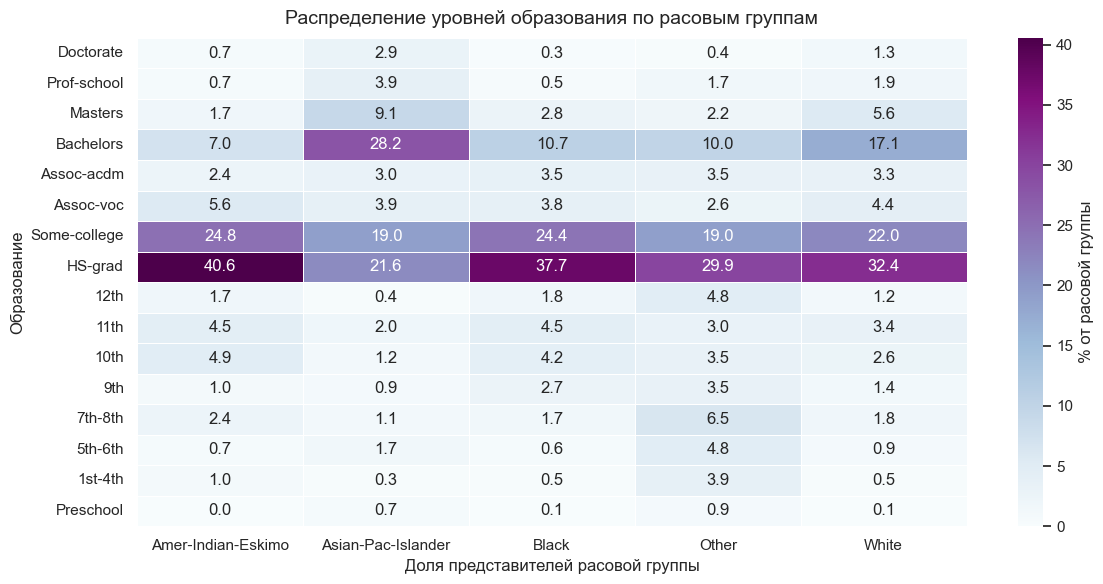

In [32]:
# распределение уровней образования по расам
plt.figure(figsize=(12, 6))

edu_race_dist = pd.crosstab(adultdf['education'], adultdf['race'], normalize='columns') * 100
edu_order = adultdf[['education', 'education-num']].drop_duplicates().sort_values('education-num')['education'].tolist()

# упорядочиваем строки по возрастанию уровня образования
edu_race_dist = edu_race_dist.loc[edu_order]
ax = sns.heatmap(edu_race_dist, cmap='BuPu', annot=True, fmt='.1f', linewidths=0.5, cbar_kws={'label': '% от расовой группы'})

plt.title('Распределение уровней образования по расовым группам', fontsize=14, pad=10)
plt.xlabel('Доля представителей расовой группы')
plt.ylabel('Образование')
plt.xticks(rotation=0)  # подписи рас горизонтально

# инвертируем ось Y
ax.invert_yaxis()

plt.tight_layout()
plt.show()

Тепловая карта распределения уровней образования по расовым группам наглядно демонстрирует структурное неравенство в доступе к знаниям. Белое население и азиаты доминируют в категориях, требующих длительных лет обучения, таких как бакалавриат, магистратура и профессиональные степени. Эти группы формируют основу интеллектуального и управленческого класса общества.

В то же время расовые меньшинства, в частности афроамериканцы и латиноамериканцы, оказываются перепредставлены в нижних и средних эшелонах образовательной пирамиды. Хотя среди них есть успешные специалисты с высшим образованием, массовый характер носит наличие только среднего образования или его неполных форм. Это создает порочный круг: отсутствие доступа к качественному образованию на ранних этапах жизни ограничивает возможности получения высокооплачиваемой профессии в будущем, что, в свою очередь, не позволяет следующим поколениям инвестировать в престижное образование, закрепляя расовую стратификацию.

<a id=6.3.></a>
### 6.3. Расовое неравенство в типах занятости

<Figure size 1400x600 with 0 Axes>

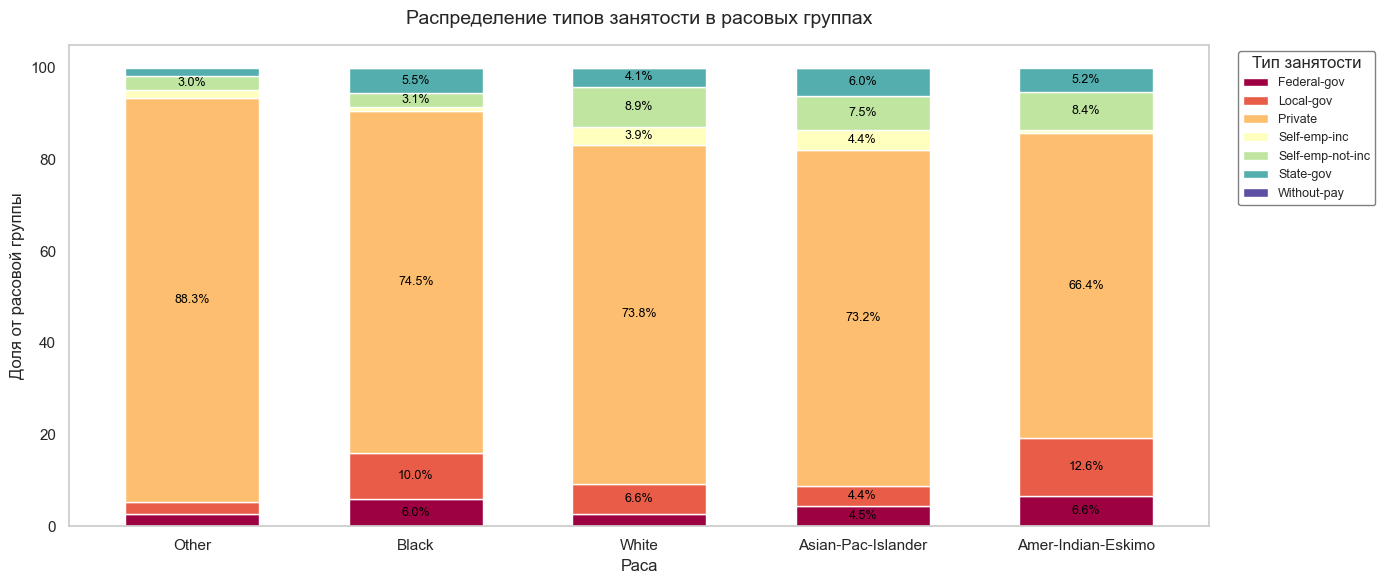

In [33]:
# расовое неравенство в типах трудовой деятельности
plt.figure(figsize=(14, 6))

# считаем распределение типов занятости по расам (в %)
race_workclass = pd.crosstab(adultdf['race'], adultdf['workclass'], normalize='index') * 100

# упорядочиваем расы по убыванию доли частного сектора занятости
race_order = race_workclass['Private'].sort_values(ascending=False).index.tolist()
race_workclass = race_workclass.loc[race_order]

# строим stacked bar chart
ax = race_workclass.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='Spectral', width=0.6)

plt.title('Распределение типов занятости в расовых группах', fontsize=14, pad=15)
plt.xlabel('Раса', fontsize=12)
plt.ylabel('Доля от расовой группы', fontsize=12)
plt.xticks(rotation=0)

# легенда
legend = ax.legend(title='Тип занятости', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, facecolor='white', edgecolor='gray', framealpha=1)

# добавляем подписи долей в каждом сегменте столбцов
for i in range(len(race_workclass)):
    cumulative_height = 0
    for j, workclass in enumerate(race_workclass.columns):
        value = race_workclass.iloc[i, j]
        if value >= 3:  # показываем только сегменты >= 3%
            ax.text(i, cumulative_height + value/2, f'{value:.1f}%', ha='center', va='center', fontsize=9, color='black')
        cumulative_height += value

ax.grid(False)
plt.tight_layout()
plt.show()

Анализ типов занятости в разрезе расовых групп закрепляет картину экономического неравенства на уровне структуры рынка труда. Меньшинства статистически реже представлены в сферах самоуправления, государственного управления высокого уровня и высокотехнологичного частного сектора. Они оказываются сконцентрированы в традиционном частном секторе, который, как было установлено ранее, является основным резервуаром низкооплачиваемых и рутинных позиций.

Такое распределение указывает на то, что расовые меньшинства сталкиваются с барьерами при попытке начать собственный бизнес или занять руководящие должности. Они чаще остаются в уязвимых позициях наемных работников без социальных лифтов, зависящих от решений работодателей. Расовая сегрегация в типах занятости лишает эти группы возможности накапливать капитал, влиять на экономическую повестку и обеспечивать финансовую устойчивость для своих семей, воспроизводя неравенство из поколения в поколение.

<a id=7></a>
## Шаг 7. Семейная структура и её влияние

<a id=7.1.></a>
### 7.1. Влияние семейного положения на рабочие часы

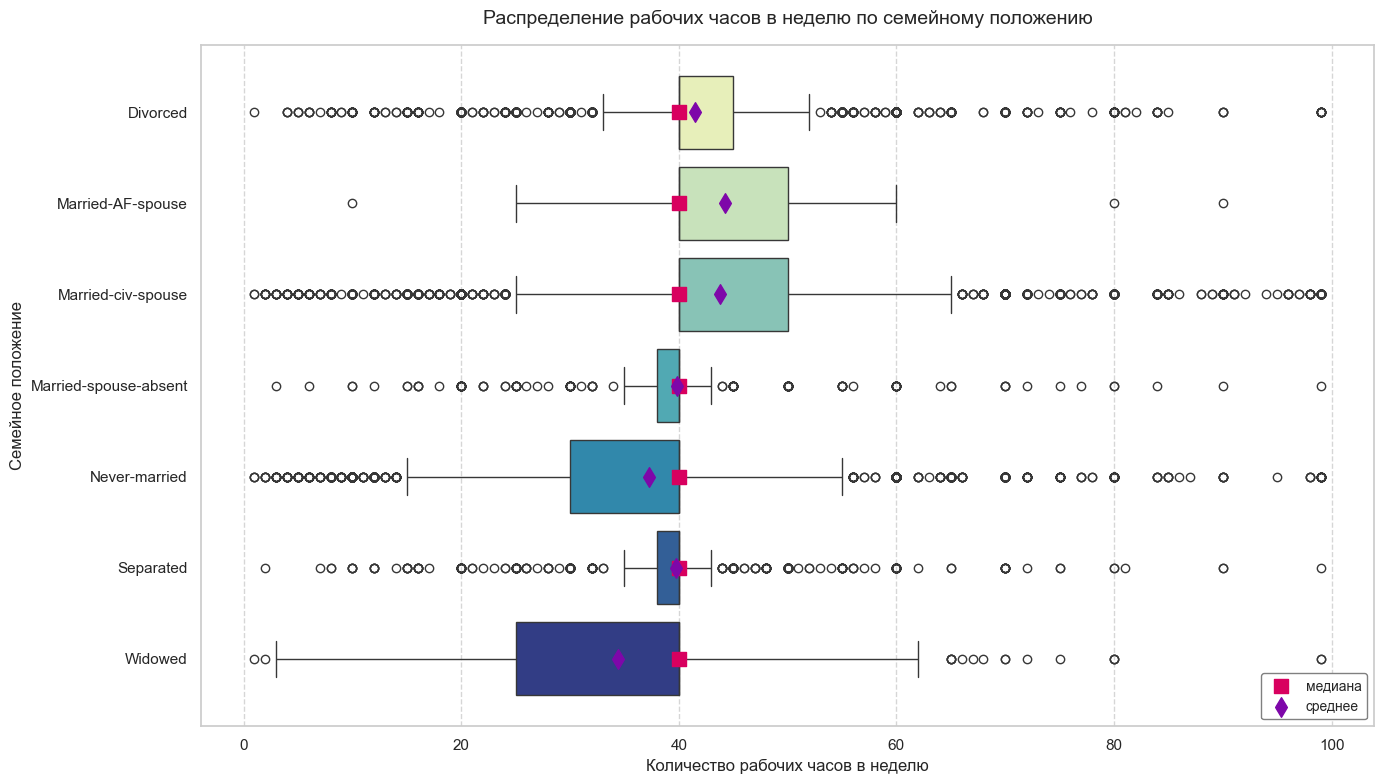

In [34]:
# визуализация: рабочие часы в разрезе семейного положения (горизонтальные боксплоты)
plt.figure(figsize=(14, 8))

# рассчитываем среднее и медиану для каждой категории
marital_stats = adultdf.groupby('marital-status')['hours-per-week'].agg(['mean', 'median']).sort_values('median', ascending=True)

# создаём горизонтальный боксплот
ax = sns.boxplot(data=adultdf, x='hours-per-week', y='marital-status', palette='YlGnBu', order=marital_stats.index)

ax.set_title('Распределение рабочих часов в неделю по семейному положению', fontsize=14, pad=15)
ax.set_xlabel('Количество рабочих часов в неделю', fontsize=12)
ax.set_ylabel('Семейное положение', fontsize=12)

# добавляем обозначения для среднего и медианы
for i, (marital, row) in enumerate(marital_stats.iterrows()):
    # медиана
    ax.scatter(row['median'], i, marker='s', color='#D8005F', s=100, zorder=5, label='медиана' if i == 0 else "")

    # среднее
    ax.scatter(row['mean'], i, marker='d', color='#7E07A9', s=100, zorder=6, label='среднее' if i == 0 else "")

# легенда для обозначений среднего и медианы
legend = ax.legend(loc='lower right', fontsize=10, facecolor='white', edgecolor='gray', framealpha=1)
legend.set_zorder(100)

# сетка только по оси X
ax.grid(axis='x', linestyle='--', alpha=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Семейная структура выступает мощным модификатором трудовых траекторий, что отчетливо видно при анализе количества рабочих часов в неделю. Люди, состоящие в браке, работают значительно больше всех остальных групп. Это связано с повышенной финансовой ответственностью за семью, необходимостью обеспечения супруга и детей, а также с традиционными гендерными ролями, где мужья берут на себя роль главных кормильцов.

В то же время холостые, разведенные или вдовствующие респонденты, а также те, кто никогда не вступал в брак, статистически работают меньше. Отсутствие необходимости содержать иждивенцев позволяет им выбирать более комфортный график или работать в режиме частичной занятости. Таким образом, семейное положение напрямую диктует интенсивность трудовой отдачи: наличие семьи выступает своего рода экономическим стимулом, заставляющим человека жертвовать личным временем ради повышения совокупного дохода домохозяйства.

<a id=7.2.></a>
### 7.2. Влияние семейного положения на доход в разрезе гендерного признака

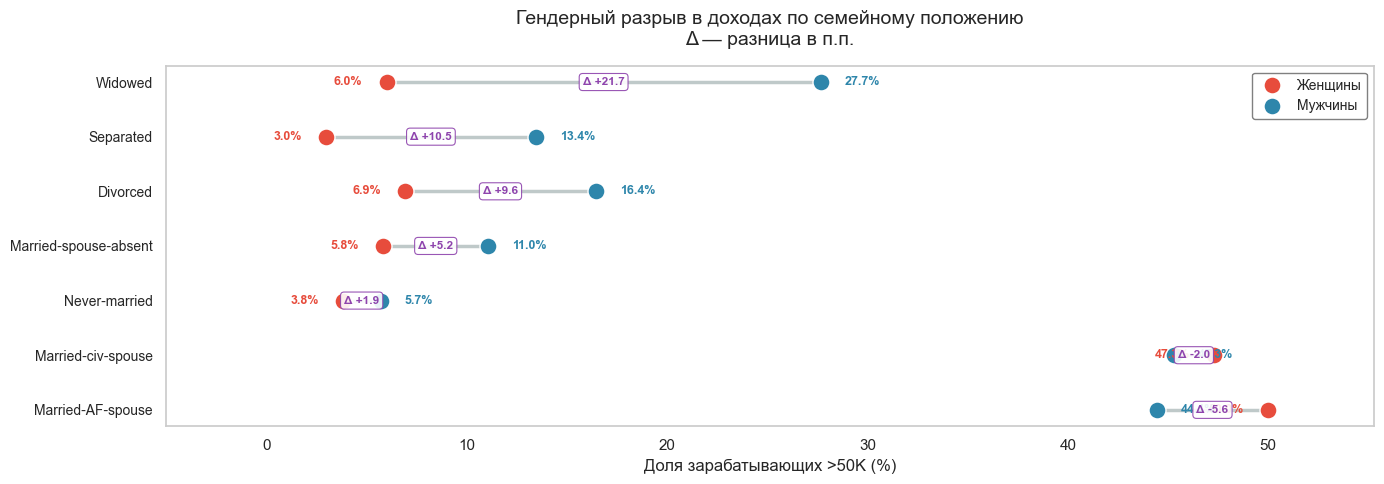

In [35]:
# гантельный график: гендерный разрыв по семейному положению

# считаем долю >50K в разрезе семейного положения и пола
marital_sex_salary = adultdf.groupby(['marital-status', 'sex'])['salary'].apply(lambda x: (x == '>50K').mean() * 100).unstack()

# рассчитываем разрыв и сортируем по его величине
marital_sex_salary['gap'] = marital_sex_salary['Male'] - marital_sex_salary['Female']
marital_sex_salary = marital_sex_salary.sort_values('gap', ascending=True)

# создаём фигуру
fig, ax = plt.subplots(figsize=(14, 5))
y_pos = range(len(marital_sex_salary))

# линии-гантели (серые)
for i, (marital, row) in enumerate(marital_sex_salary.iterrows()):
    ax.plot([row['Female'], row['Male']], [i, i], color='#95A5A6', linewidth=2.5, alpha=0.6, zorder=1)

# точки: женщины (красные)
ax.scatter(marital_sex_salary['Female'], y_pos, color='#E74C3C', s=150, zorder=3, edgecolor='white', linewidth=1, label='Женщины')

# точки: мужчины (синие)
ax.scatter(marital_sex_salary['Male'], y_pos, color='#2E86AB', s=150, zorder=3, edgecolor='white', linewidth=1, label='Мужчины')

# подписи значений у точек
offset = 1.2
for i, (marital, row) in enumerate(marital_sex_salary.iterrows()):
    # женщины — слева от точки
    ax.text(row['Female'] - offset, i, f'{row["Female"]:.1f}%', va='center', ha='right', fontsize=9, color='#E74C3C', fontweight='bold')
    # мужчины — справа от точки
    ax.text(row['Male'] + offset, i, f'{row["Male"]:.1f}%', va='center', ha='left', fontsize=9, color='#2E86AB', fontweight='bold')
    
    # разрыв в центре гантели
    mid_point = (row['Male'] + row['Female']) / 2
    ax.text(mid_point, i, f'Δ {row["gap"]:+.1f}', ha='center', va='center', fontsize=8.5, 
            color='#8E44AD', fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#8E44AD', alpha=0.9, linewidth=0.8))

# оформление
ax.set_yticks(y_pos)
ax.set_yticklabels(marital_sex_salary.index, fontsize=10)
ax.set_xlabel('Доля зарабатывающих >50K (%)', fontsize=12)
ax.set_title('Гендерный разрыв в доходах по семейному положению\n''Δ — разница в п.п.', fontsize=14, pad=15)
ax.grid(False)

# расширяем xlim для подписей
max_val = marital_sex_salary['Male'].max()
min_val = marital_sex_salary['Female'].min()
ax.set_xlim(min_val - 8, max_val + 10)

# легенда
legend = ax.legend(loc='upper right', fontsize=10, facecolor='white', edgecolor='gray', framealpha=1)
legend.set_zorder(100)

plt.tight_layout()
plt.show()

Гендерный анализ доходов в разрезе семейного положения выявляет парадокс брака, который по-разному влияет на мужчин и женщин. Для мужчин женитьба является мощным катализатором роста доходов: статус главы семьи коррелирует с максимальным процентом высоких заработков. Вероятно, это обусловлено наличием «тыла», повышенной мотивацией и тем, что работодатели подсознательно воспринимают женатых мужчин как более надежных и ответственных сотрудников, достойных повышения.

Для женщин замужество, напротив, часто коррелирует со снижением шансов на высокий доход или отсутствием такого выраженного эффекта, как у мужчин. Гендерный разрыв достигает своих максимальных значений именно в категории состоящих в браке. Это подтверждает теорию о том, что традиционный брак часто перекладывает бремя домашних обязанностей и ухода за детьми на женщину, вынуждая ее сокращать рабочее время, отказываться от карьерных амбиций или выбирать менее оплачиваемую, но более гибкую работу, в то время как мужчина полностью концентрируется на профессиональном росте.

<a id=7.3.></a>
### 7.3. Соотношение семейного положения и уровня дохода

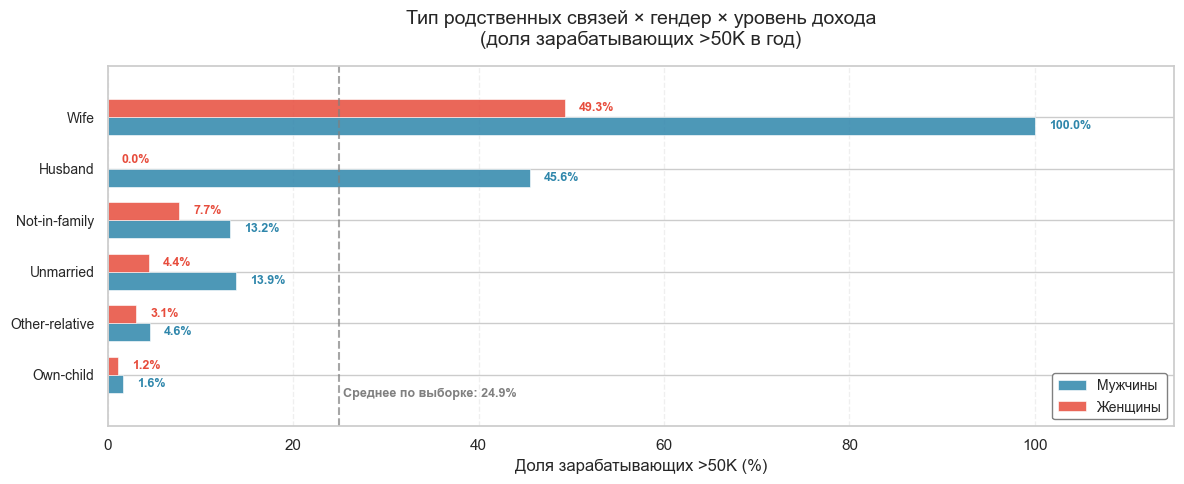

In [36]:
# визуализация: тип родственных связей × гендер × доход (>50K)

# считаем долю >50K в разрезе relationship и sex
relationship_sex_salary = adultdf.groupby(['relationship', 'sex'])['salary'].apply(lambda x: (x == '>50K').mean() * 100).unstack()

# сортируем по среднему значению (мужчины + женщины)
relationship_sex_salary['avg'] = (relationship_sex_salary['Male'] + relationship_sex_salary['Female']) / 2
relationship_sex_salary = relationship_sex_salary.sort_values('avg', ascending=True)

# создаём фигуру
fig, ax = plt.subplots(figsize=(12, 5))

# позиции по оси Y
y_pos = range(len(relationship_sex_salary))
bar_width = 0.35

# сдвоенные столбцы: мужчины (синий), женщины (красный)
bars_male = ax.barh([i - bar_width/2 for i in y_pos], relationship_sex_salary['Male'], height=bar_width, label='Мужчины', color='#2E86AB', alpha=0.85, edgecolor='white', linewidth=0.5)

bars_female = ax.barh([i + bar_width/2 for i in y_pos], relationship_sex_salary['Female'], height=bar_width, label='Женщины', color='#E74C3C', alpha=0.85, edgecolor='white', linewidth=0.5)

# подписи процентов у края каждого столбца
offset = 1.5
for i, (relationship, row) in enumerate(relationship_sex_salary.iterrows()):
    # мужчины — синий
    ax.text(row['Male'] + offset, i - bar_width/2, f'{row["Male"]:.1f}%', va='center', ha='left', fontsize=9, color='#2E86AB', fontweight='bold')
    # женщины — красный
    ax.text(row['Female'] + offset, i + bar_width/2, f'{row["Female"]:.1f}%', va='center', ha='left', fontsize=9, color='#E74C3C', fontweight='bold')

# вертикальная линия — среднее по всей выборке
overall_mean = (adultdf['salary'] == '>50K').mean() * 100
ax.axvline(overall_mean, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(overall_mean + 0.5, -0.5, f'Среднее по выборке: {overall_mean:.1f}%', va='bottom', ha='left', fontsize=9, color='gray', fontweight='bold')

# оформление
ax.set_yticks(y_pos)
ax.set_yticklabels(relationship_sex_salary.index, fontsize=10)
ax.set_xlabel('Доля зарабатывающих >50K (%)', fontsize=12)
ax.set_title('Тип родственных связей × гендер × уровень дохода\n' '(доля зарабатывающих >50K в год)', fontsize=14, pad=15)

# сетка
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
max_val = max(relationship_sex_salary['Male'].max(), relationship_sex_salary['Female'].max())
ax.set_xlim(0, max_val + 15)
ax.set_ylim(-1, len(relationship_sex_salary))

legend = ax.legend(loc='lower right', fontsize=10, facecolor='white', edgecolor='gray', framealpha=1)
legend.set_zorder(100)

plt.tight_layout()
plt.show()

Анализ родственных связей и уровня дохода дополнительно иллюстрирует экономическое неравенство внутри домохозяйств. Категория «муж» имеет абсолютный максимум по доле высоких доходов, тогда как категория «жена» демонстрирует значительно меньшие показатели, несмотря на то, что они живут в одних и тех же семьях и, казалось бы, должны иметь схожий доступ к ресурсам.

Люди, не состоящие в родственных связях с главой домохозяйства, а также сироты или иные родственники, статистически чаще оказываются в группе с низким доходом. Это подчеркивает, что успех в обществе тесно связан с институтом традиционной семьи, которая выступает не только социальной, но и экономической единицей, способной аккумулировать ресурсы. Те, кто выпадает из этой традиционной структуры, оказываются в зоне повышенной финансовой уязвимости, лишенные поддержки и совместного ведения хозяйства.

<a id=7.4.></a>
### 7.4. Влияние наличия детей на рабочие часы и уровень дохода

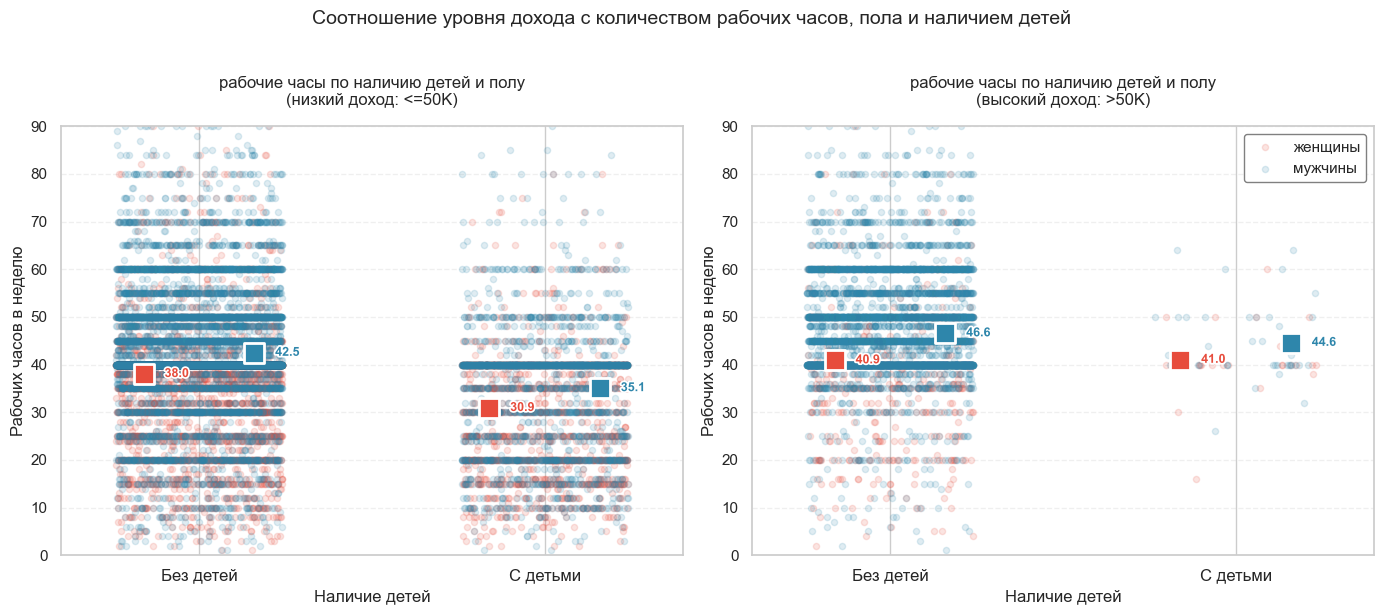

In [37]:
# визуализация: рабочие часы × наличие детей × гендер × доход
# создаём категорию "наличие детей"
adultdf['has_child'] = adultdf['relationship'].apply(lambda x: 'Без детей' if 'child' not in x.lower() else 'С детьми')

# создаём фигуру с двумя сабплотами для двух уровней дохода
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# добавляем джиттер
adultdf['child_jitter'] = adultdf['has_child'].map({'Без детей': 0.25, 'С детьми': 0.75}) + np.random.uniform(-0.12, 0.12, len(adultdf))

# цикл по двум уровням дохода
for idx, (salary_level, color_title) in enumerate([('<=50K', 'низкий доход'), ('>50K', 'высокий доход')]):
    ax = axes[idx]
    subset = adultdf[adultdf['salary'] == salary_level]
    
    # женщины — красным цветом
    female_data = subset[subset['sex'] == 'Female']
    ax.scatter(female_data['child_jitter'], female_data['hours-per-week'], color='#E74C3C', alpha=0.15, s=20, label='женщины', zorder=2)
    
    # мужчины — синим цветом
    male_data = subset[subset['sex'] == 'Male']
    ax.scatter(male_data['child_jitter'], male_data['hours-per-week'], color='#2E86AB', alpha=0.15, s=20, label='мужчины', zorder=2)
    
    # средние значения
    for i, (child_label, x_base) in enumerate([('Без детей', 0.25), ('С детьми', 0.75)]):
        for sex, color, marker in [('Female', '#E74C3C', 's'), ('Male', '#2E86AB', 's')]:
            group = subset[(subset['has_child'] == child_label) & (subset['sex'] == sex)]
            if len(group) > 0:
                mean_hours = group['hours-per-week'].mean()
                x_pos = x_base + (0.08 if sex == 'Male' else -0.08)
                
                ax.scatter(x_pos, mean_hours, color=color, s=200, marker=marker, edgecolor='white', linewidth=2, zorder=5)
                ax.text(x_pos + 0.03, mean_hours, f'{mean_hours:.1f}', va='center', ha='left', fontsize=9, fontweight='bold', color=color, path_effects=[path_effects.withStroke(linewidth=2.5, foreground='white')])

    # оформление
    ax.set_xticks([0.25, 0.75])
    ax.set_xticklabels(['Без детей', 'С детьми'], fontsize=12, )
    ax.set_xlabel('Наличие детей', fontsize=12)
    ax.set_ylabel('Рабочих часов в неделю', fontsize=12)
    ax.set_title(f'рабочие часы по наличию детей и полу\n({color_title}: {salary_level})', fontsize=12, pad=15)
    ax.set_xlim(0.05, 0.95)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_ylim(0, 90)
    
    if idx == 1:  # легенда только на правом графике
        legend = ax.legend(loc='upper right', fontsize=11, facecolor='white', edgecolor='gray', framealpha=1)
        legend.set_zorder(100)

plt.suptitle('Соотношение уровня дохода с количеством рабочих часов, пола и наличием детей', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Визуализация соотношения уровня дохода, количества рабочих часов, пола и наличия детей наглядно демонстрирует феномен «штрафа за материнство» и «премии за отцовство». Наличие детей заставляет мужчин увеличивать рабочее время и активнее бороться за высокий доход, что отражает действие традиционных установок о роли отца-кормильца. Мужчины с детьми статистически чаще работают сверхурочно и занимают высокооплачиваемые позиции.

В то же время женщины с детьми часто вынуждены сокращать рабочие часы или оставаться в сегменте низких доходов из-за необходимости ухода за ребенком. Отсутствие доступной системы дошкольного образования или гибких графиков вынуждает матерей жертвовать карьерой ради семьи. В результате наличие детей становится фактором, который поляризует экономические траектории родителей: отцы богатеют, а матери теряют в доходах и профессиональном статусе, что закрепляет гендерное неравенство на уровне следующего поколения.

<a id=8></a>
## Шаг 8. Финансовая уязвимость и капитал

<a id=8.1.></a>
### 8.1. Распределение доходов и потерь капитала в соответствии с типом занятости

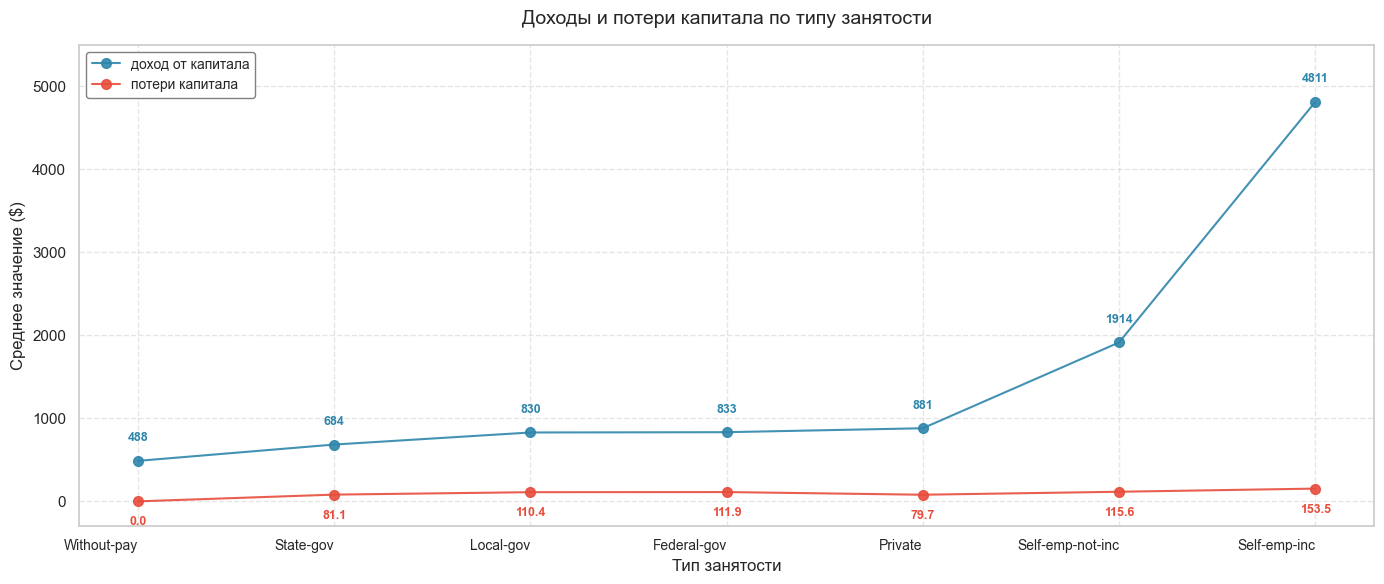

In [38]:
# визуализация: capital-gain и capital-loss

# группируем по workclass и считаем средние значения
workclass_capital = adultdf.groupby('workclass').agg(capital_gain=('capital-gain', 'mean'), capital_loss=('capital-loss', 'mean')).reset_index()

# сортируем по capital-gain для упорядоченности
workclass_capital = workclass_capital.sort_values('capital_gain', ascending=True).reset_index(drop=True)

# создаём фигуру
fig, ax = plt.subplots(figsize=(14, 6))
x_pos = range(len(workclass_capital))

ax.plot(x_pos, workclass_capital['capital_gain'], marker='o', linewidth=1.5, markersize=7, color='#2E86AB', alpha=0.9, label='доход от капитала', zorder=3)
ax.plot(x_pos, workclass_capital['capital_loss'], marker='o', linewidth=1.5, markersize=7, color='#E74C3C', alpha=0.9, label='потери капитала', zorder=3)

# подписи значений — используем enumerate для правильных позиций
for idx, (_, row) in enumerate(workclass_capital.iterrows()):
    ax.text(idx, row['capital_gain'] + 200, f'{row["capital_gain"]:.0f}', ha='center', va='bottom', fontsize=9, color='#2E86AB', fontweight='bold')
    ax.text(idx, row['capital_loss'] - 180, f'{row["capital_loss"]:.1f}', ha='center', va='top', fontsize=9, color='#E74C3C', fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(workclass_capital['workclass'], fontsize=10, ha='right')
ax.set_xlabel('Тип занятости', fontsize=12)
ax.set_ylabel('Среднее значение ($)', fontsize=12)
ax.set_title('Доходы и потери капитала по типу занятости', fontsize=14, pad=15)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

max_gain = workclass_capital['capital_gain'].max()
ax.set_ylim(-300, 5500)

legend = ax.legend(loc='upper left', fontsize=10, facecolor='white', edgecolor='gray', framealpha=1)
legend.set_zorder(100)

plt.tight_layout()
plt.show()

Анализ финансовых рынков и инвестиций показывает, что капитал — это привилегия узкой прослойки общества, тесно связанная с типом занятости. Основной объем доходов от капитала генерируется самозанятыми с инкорпорированным бизнесом и успешными работниками частного сектора, которые имеют возможность реинвестировать свои сбережения. Для этих групп капитал выступает не просто дополнением к зарплате, а основным источником приумножения богатства.

В то же время государственные служащие, работники муниципального сектора и наемные сотрудники в традиционном частном секторе практически не имеют доходов от капитала. Их финансовое благополучие полностью зависит от заработной платы. Потери капитала также распределены крайне неравномерно и затрагивают преимущественно тех, кто вообще участвует в инвестиционных процессах. Таким образом, разрыв между теми, кто владеет активами, и теми, кто живет только от зарплаты, является фундаментальной чертой экономического неравенства.

<a id=8.2.></a>
### 8.2. Возраст и финансовые проблемы

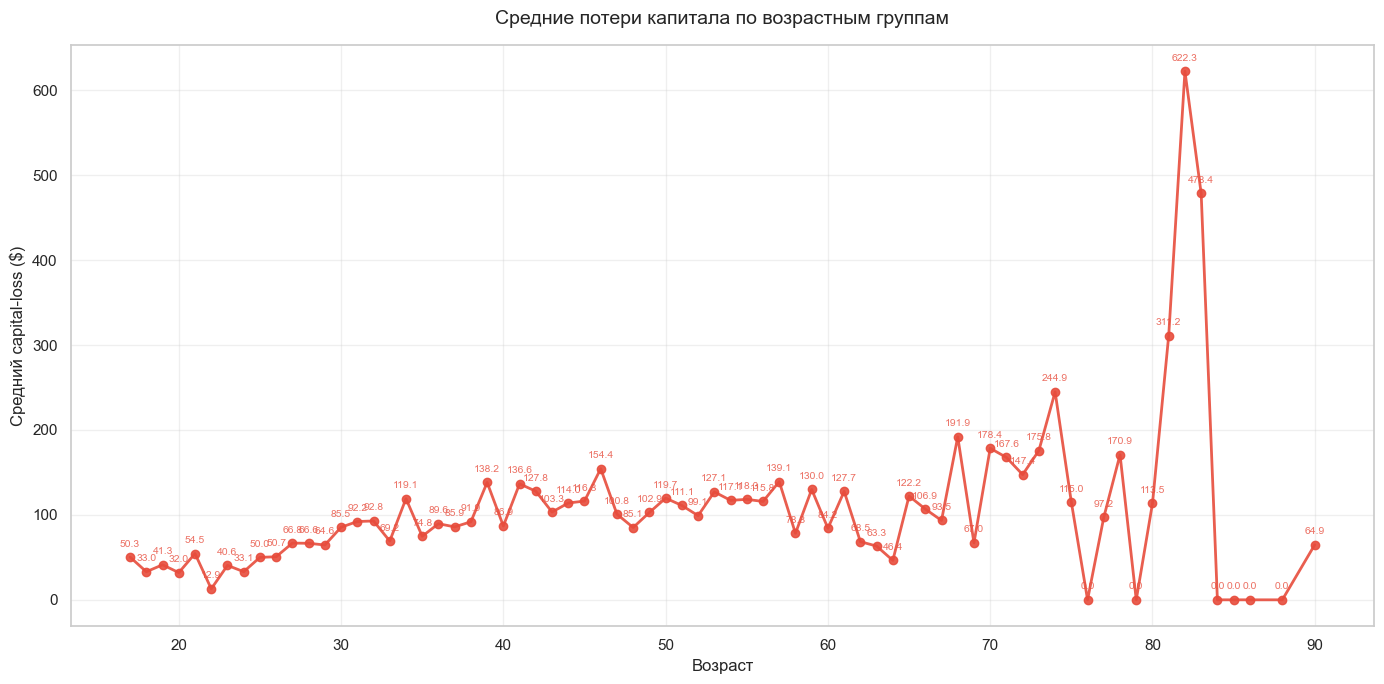

In [39]:
# визуализация: средние потери капитала по возрастным группам
plt.figure(figsize=(14, 7))
age_loss = adultdf.groupby('age')['capital-loss'].mean()

# строим линию
plt.plot(age_loss.index, age_loss.values, marker='o', linewidth=2, markersize=6, color='#E74C3C', alpha=0.9)

# подписи значений
for age, loss in age_loss.items():
    plt.text(age, loss + 10, f'{loss:.1f}', ha='center', va='bottom', fontsize=7.5, color='#E74C3C', alpha=0.8)

plt.title('Средние потери капитала по возрастным группам', fontsize=14, pad=15)
plt.xlabel('Возраст', fontsize=12)
plt.ylabel('Средний capital-loss ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Исследование потерь капитала в разрезе возраста указывает на то, что финансовые риски и рыночные колебания затрагивают преимущественно людей зрелого и пожилого возраста. Поскольку потери капитала в целом редки для основной массы населения, их наличие свидетельствует о том, что индивид обладает значительными накоплениями и активно участвует в инвестиционных или спекулятивных процессах.

Пики потерь капитала приходятся на возраст, когда люди уже накопили определенный базовый капитал и пытаются его приумножить перед выходом на пенсию. Это означает, что финансовая уязвимость перед лицом рыночных кризисов является уделом не беднейших слоев, а среднего и высшего классов, которые рискуют своими активами. Для беднейших слоев населения проблема заключается не в потере капитала, а в его изначальном отсутствии, что делает их неуязвимыми для биржевых крахов, но критически уязвимыми для любых экономических потрясений.

<a id=8.3.></a>
### 8.3. Распределение капитала по уровню дохода

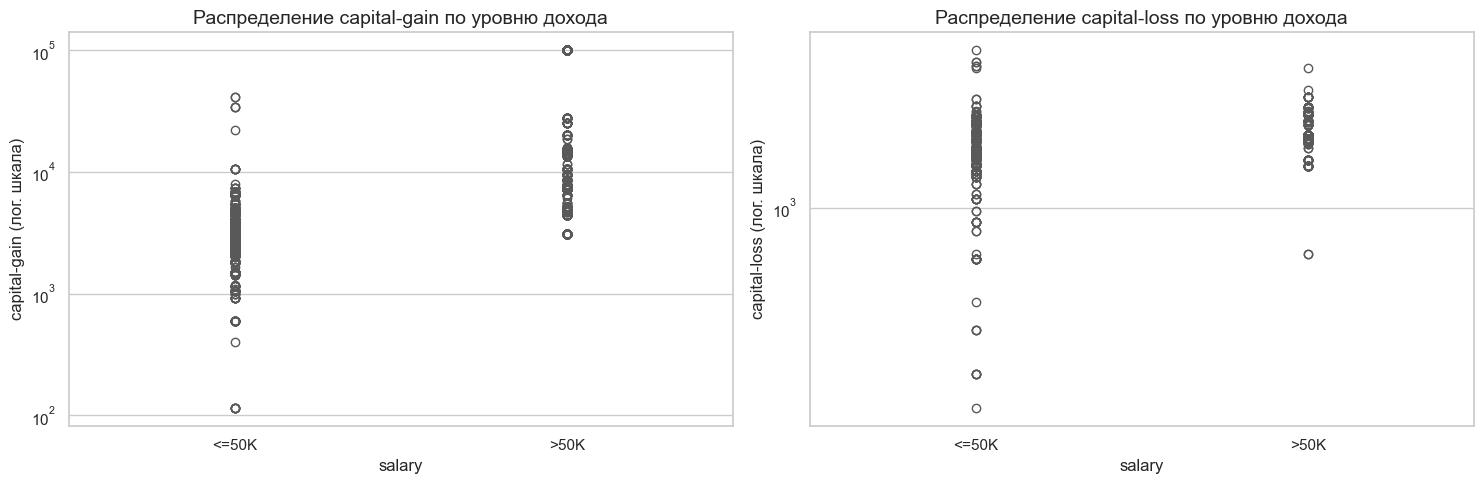

In [40]:
# визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=adultdf, x='salary', y='capital-gain', ax=axes[0], palette='Set2')
axes[0].set_title('Распределение capital-gain по уровню дохода', fontsize=14)
axes[0].set_yscale('log')
axes[0].set_ylabel('capital-gain (лог. шкала)')

sns.boxplot(data=adultdf, x='salary', y='capital-loss', ax=axes[1], palette='Set2')
axes[1].set_title('Распределение capital-loss по уровню дохода', fontsize=14)
axes[1].set_yscale('log')
axes[1].set_ylabel('capital-loss (лог. шкала)')

plt.tight_layout()
plt.show()

Графики распределения капитала по уровню дохода подводят черту под анализом финансового расслоения. Люди с низким доходом практически не имеют ни доходов, ни потерь от капитала, так как у них просто нет свободных средств для инвестирования. Их медианные значения по этим признакам равны нулю, что означает полное исключение из мира финансового капитала.

Капитал и связанные с ним риски являются эксклюзивной характеристикой высшего класса. Именно эта группа генерирует львиную долю инвестиционных доходов и несет основные финансовые потери. Это доказывает, что в обществе существует два совершенно разных экономических уклада: для большинства людей труд является единственным источником выживания, тогда как для элиты капитал работает на приумножение богатства, создавая пропасть, которую невозможно преодолеть исключительно за счет увеличения рабочих часов.

<a id=9></a>
## Шаг 9. Интегральный анализ. Кто достигает успеха в обществе?

<a id=9.1.></a>
### 9.1. Комплексный анализ заработка в зависимости от образования и возраста

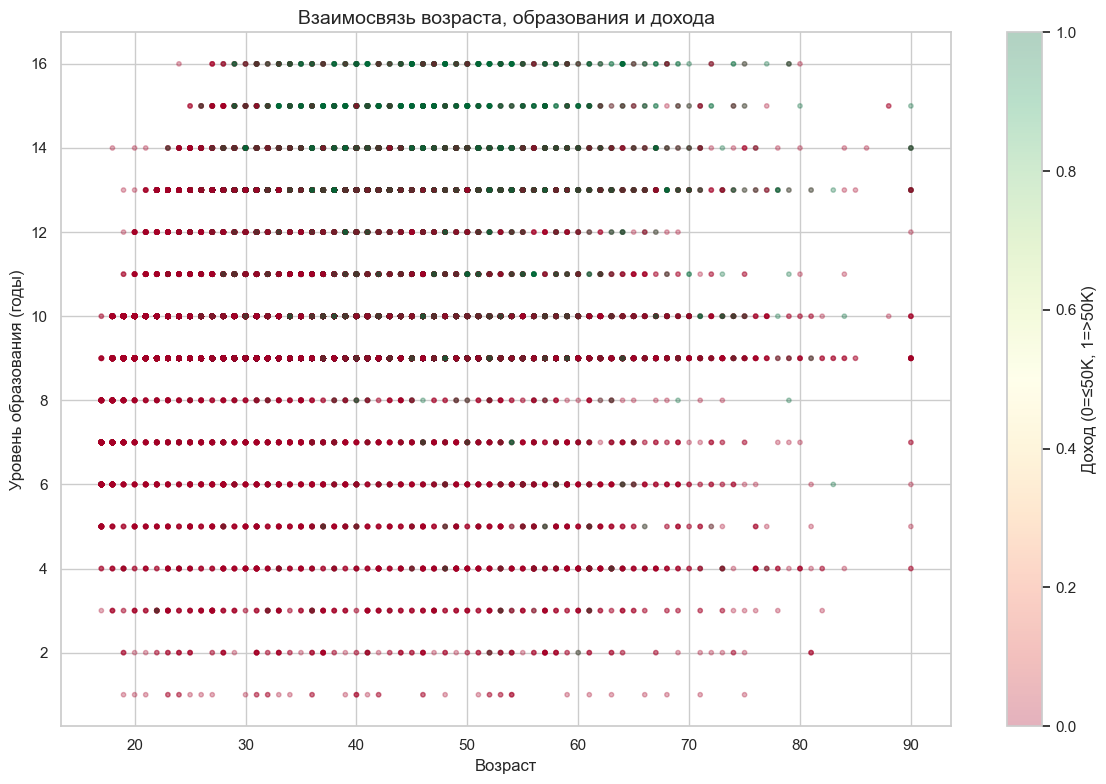

In [41]:
# визуализация
plt.figure(figsize=(12, 8))
scatter = plt.scatter(adultdf['age'], adultdf['education-num'], 
                     c=(adultdf['salary'] == '>50K').astype(int),
                     cmap='RdYlGn', alpha=0.3, s=10)
plt.title('Взаимосвязь возраста, образования и дохода', fontsize=14)
plt.xlabel('Возраст')
plt.ylabel('Уровень образования (годы)')
plt.colorbar(scatter, label='Доход (0=≤50K, 1=>50K)')
plt.tight_layout()
plt.show()

Интегральный анализ взаимосвязи возраста, образования и дохода на диаграмме рассеяния подтверждает, что формула успеха в обществе требует обязательного сочетания двух факторов: высокого уровня образования и зрелого возраста. Точки, обозначающие высокооплачиваемых респондентов, концентрируются в правой верхней части графика, где пересекаются многолетнее обучение и жизненный опыт.

Молодые образованные люди еще не достигли пика заработка, так как им требуется время для реализации своего потенциала на рынке труда. В то же время пожилые люди без образования не имеют шансов на финансовый прорыв, так как их квалификация не востребована в высокооплачиваемых секторах. Таким образом, успех не является результатом какого-то одного фактора; это синергетический эффект, где образование задает потенциальный потолок, а возраст позволяет его достичь.

<a id=9.2.></a>
### 9.2. Многомерный анализ: образование, возраст, доход

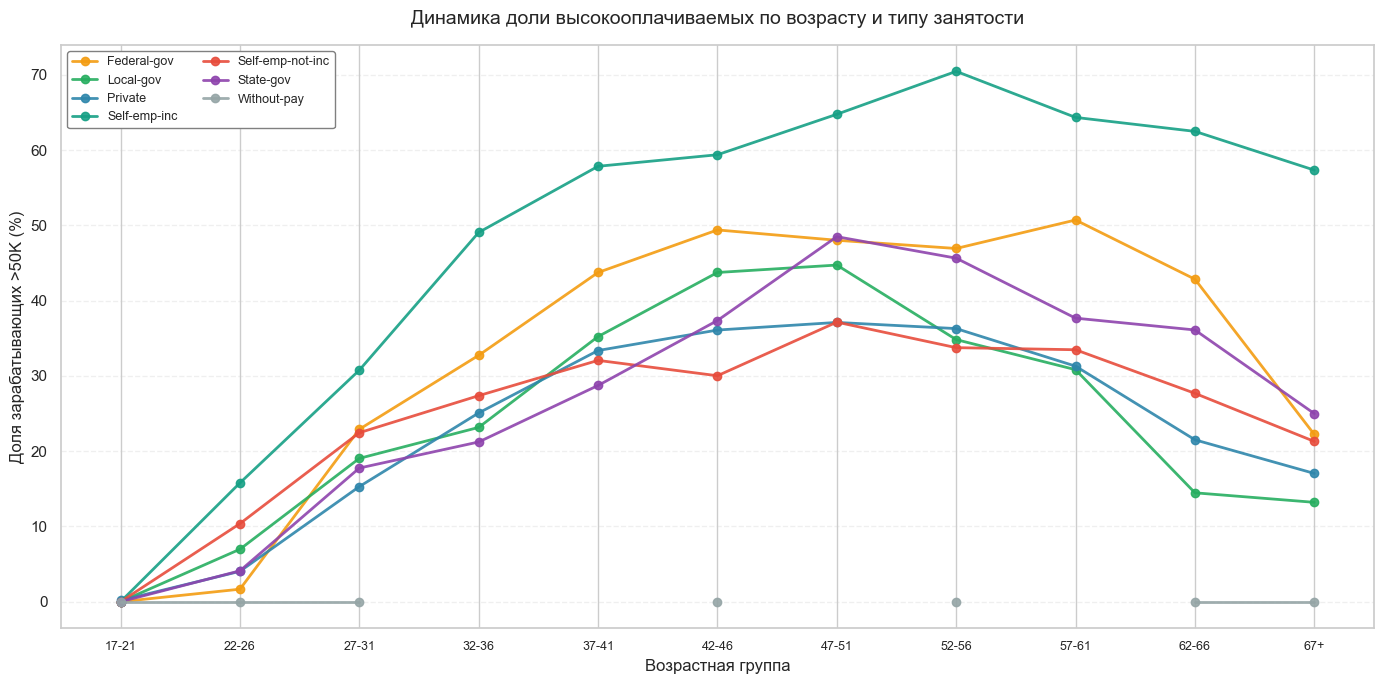

In [42]:
# визуализация: возраст × тип занятости × доля >50K (lineplot)

# создаём возрастные группы (по 5 лет для большей детализации)
bins = [17, 22, 27, 32, 37, 42, 47, 52, 57, 62, 67, 95]
labels = ['17-21', '22-26', '27-31', '32-36', '37-41', 
          '42-46', '47-51', '52-56', '57-61', '62-66', '67+']
adultdf['age_group'] = pd.cut(adultdf['age'], bins=bins, labels=labels, right=False)

# считаем долю >50K в разрезе возрастной группы и типа занятости
age_workclass_salary = adultdf.groupby(['age_group', 'workclass'])['salary'].apply(lambda x: (x == '>50K').mean() * 100).unstack()

# создаём фигуру
fig, ax = plt.subplots(figsize=(14, 7))

# цвета для типов занятости
colors = {
    'Self-emp-inc': '#16A085',
    'Federal-gov': '#F39C12',
    'Self-emp-not-inc': '#E74C3C',
    'Private': '#2E86AB',
    'State-gov': '#8E44AD',
    'Local-gov': '#27AE60',
    'Without-pay': '#95A5A6'
}

# строим линии для каждого типа занятости
x_pos = range(len(age_workclass_salary))
for workclass in age_workclass_salary.columns:
    if workclass in colors:
        ax.plot(x_pos, age_workclass_salary[workclass], marker='o', linewidth=2, markersize=6, color=colors[workclass], label=workclass, alpha=0.9)

# оформление
ax.set_xticks(x_pos)
ax.set_xticklabels(age_workclass_salary.index, ha='center', fontsize=9)
ax.set_xlabel('Возрастная группа', fontsize=12)
ax.set_ylabel('Доля зарабатывающих >50K (%)', fontsize=12)
ax.set_title('Динамика доли высокооплачиваемых по возрасту и типу занятости', fontsize=14, pad=15)

# сетка
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# легенда
legend = ax.legend(loc='upper left', fontsize=9, facecolor='white', edgecolor='gray', framealpha=1, ncol=2)
legend.set_zorder(100)

plt.tight_layout()
plt.show()

Многомерный анализ динамики доли высокооплачиваемых по возрасту и типу занятости показывает, что карьерные траектории в разных секторах экономики развиваются по-разному. Самозанятые с инкорпорированным бизнесом выходят на пик доходов значительно раньше, уже в возрасте 30–40 лет, что отражает специфику предпринимательской деятельности, где риски и награды приходят быстро.

В то же время наемные работники в частном и государственном секторах достигают пика своих доходов позже, к 50 годам и старше. Это свидетельствует о том, что корпоративные и бюрократические системы вознаграждают за выслугу лет, постепенное накопление опыта и лояльность. Разные типы занятости предлагают совершенно разные жизненные сценарии: быстрый предпринимательский риск против медленного, но стабильного карьерного роста в найме.

<a id=9.3.></a>
### 9.3. Факторы успеха: сводная таблица

Гендерный дисбаланс в социальных траекториях успеха.

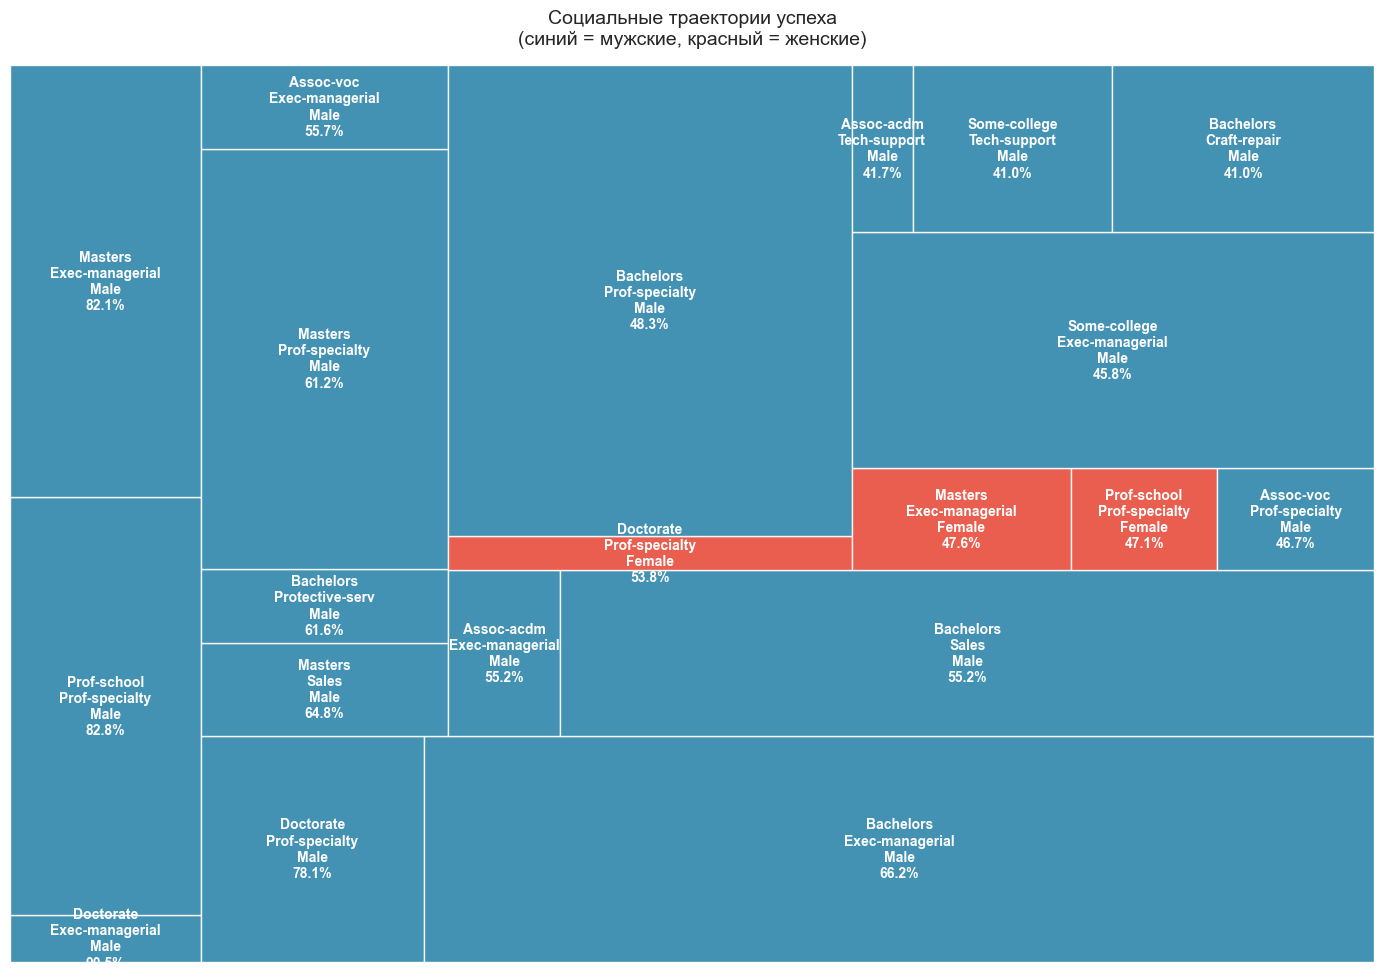


ГЕНДЕРНЫЙ ДИСБАЛАНС В СОЦИАЛЬНЫХ ТРАЕКТОРИЯХ УСПЕХА
Всего успешных стратегий (>50% дохода, n>50): 20
  → Мужских: 17 (85.0%)
  → Женских: 3 (15.0%)

Коэффициент гендерного неравенства: 5.7:1



In [43]:
# агрегация
combo_stats = adultdf.groupby(['education', 'occupation', 'sex']).agg(count=('salary', 'size'), success_rate=('salary', lambda x: (x == '>50K').mean() * 100)).reset_index()

# фильтрация
top_combos = combo_stats[(combo_stats['success_rate'] > 40) & (combo_stats['count'] > 40)].copy().sort_values('success_rate', ascending=False).head(20)

# цветовое разделение по гендерному признаку
color_map = {'Male': '#2E86AB', 'Female': '#E74C3C'}
colors = [color_map[sex] for sex in top_combos['sex']]

# подписи
top_combos['label'] = top_combos.apply(lambda row: f"{row['education']}\n{row['occupation']}\n{row['sex']}\n{row['success_rate']:.1f}%", axis=1)

# отрисовка
fig, ax = plt.subplots(figsize=(14, 10))
squarify.plot(sizes=top_combos['count'], label=top_combos['label'], color=colors, alpha=0.9, ax=ax, pad=False, text_kwargs={'fontsize': 10, 'color': 'white', 'fontweight': 'bold'})

ax.set_title('Социальные траектории успеха\n(синий = мужские, красный = женские)', fontsize=14, pad=15)
ax.axis('off')

plt.tight_layout()
plt.show()

# вывод статистики
gender_counts = top_combos['sex'].value_counts()
print(f"\n{'='*60}")
print(f"ГЕНДЕРНЫЙ ДИСБАЛАНС В СОЦИАЛЬНЫХ ТРАЕКТОРИЯХ УСПЕХА")
print(f"{'='*60}")
print(f"Всего успешных стратегий (>50% дохода, n>50): {len(top_combos)}")
print(f"  → Мужских: {gender_counts.get('Male', 0)} ({gender_counts.get('Male', 0)/len(top_combos)*100:.1f}%)")
print(f"  → Женских: {gender_counts.get('Female', 0)} ({gender_counts.get('Female', 0)/len(top_combos)*100:.1f}%)")
print(f"\nКоэффициент гендерного неравенства: {gender_counts.get('Male', 0) / max(gender_counts.get('Female', 1), 1):.1f}:1")
print(f"{'='*60}\n")

Сводный анализ социальных траекторий успеха, визуализированный в виде древовидной карты, шокирует своим гендерным дисбалансом. Из всех выявленных «успешных стратегий» — комбинаций образования и профессий, дающих более 50% шанс на высокий доход, — подавляющее большинство принадлежит мужчинам. Женские траектории успеха искусственно сужены и представлены лишь несколькими нишами.

Коэффициент гендерного неравенства достигает почти шестикратного перевеса в пользу мужчин. Это математическое подтверждение того, что общество предлагает мужчинам значительно более широкий спектр легальных и эффективных способов достижения финансового благополучия. Женщины, даже обладая аналогичным образованием и амбициями, вынуждены пробиваться через узкие коридоры возможностей, в то время как мужчины имеют доступ к широким магистралям карьерного роста.

<a id=9.4.></a>
### 9.4. Статистический анализ: какие факторы наиболее значимы для уровня доходов?

In [44]:
# критерий хи-квадрат для категориальных переменных
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation', 
                   'relationship', 'race', 'sex', 'native-country']

chi_square_results = []
for col in categorical_cols:
    contingency = pd.crosstab(adultdf[col], adultdf['salary'])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    chi_square_results.append({
        'Feature': col,
        'Chi2': chi2,
        'p-value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

chi_square_df = pd.DataFrame(chi_square_results)
chi_square_df = chi_square_df.sort_values('Chi2', ascending=False)

print("Статистическая значимость факторов для уровня дохода:")
print(chi_square_df.to_string(index=False))

Статистическая значимость факторов для уровня дохода:
       Feature   Chi2  p-value Significant
  relationship 6225.9  0.0e+00         Yes
marital-status 6053.3  0.0e+00         Yes
     education 4065.5  0.0e+00         Yes
    occupation 3682.0  0.0e+00         Yes
           sex 1413.3 2.7e-309         Yes
     workclass  801.4 7.8e-170         Yes
native-country  315.5  1.7e-44         Yes
          race  304.2  1.4e-64         Yes


Статистический анализ с использованием критерия хи-квадрат математически доказывает, что все рассмотренные демографические и социальные факторы являются статистически значимыми предикторами уровня дохода. Наибольшее влияние оказывают семейное положение, образование и профессия, что подтверждает ключевую роль человеческого капитала и социальной структуры.

Однако пол и раса также остаются высокозначимыми факторами, что подтверждает наличие системного неравенства, не сводимого только к различиям в выборе профессии или образовании. Даже при контроле этих переменных, принадлежность к определенному полу или расовой группе продолжает оказывать независимое влияние на финансовые шансы индивида. Это указывает на то, что алгоритмы и модели, игнорирующие эти факторы, могут воспроизводить и усиливать скрытую дискриминацию, заложенную в самом обществе.

<a id=9.5.></a>
### 9.5. Портрет успешного респондента

In [45]:
print("\n" + "="*60)
print("ПОРТРЕТ УСПЕШНОГО РЕСПОНДЕНТА (зарабатывающего >50K)")
print("="*60)

high_earners = adultdf[adultdf['salary'] == '>50K']
low_earners = adultdf[adultdf['salary'] == '<=50K']

print(f"\nСредний возраст: {high_earners['age'].mean():.1f} лет (vs {low_earners['age'].mean():.1f})")
print(f"Средний уровень образования: {high_earners['education-num'].mean():.1f} категория (vs {low_earners['education-num'].mean():.1f})")
print(f"Среднее количество рабочих часов: {high_earners['hours-per-week'].mean():.1f} (vs {low_earners['hours-per-week'].mean():.1f})")

print(f"\nНаиболее распространенный тип занятости: {high_earners['workclass'].mode()[0]}")
print(f"Наиболее распространенное образование: {high_earners['education'].mode()[0]}")
print(f"Наиболее распространенная профессия: {high_earners['occupation'].mode()[0]}")
print(f"Наиболее распространенное семейное положение: {high_earners['marital-status'].mode()[0]}")
print(f"Наиболее распространенная раса: {high_earners['race'].mode()[0]}")
print(f"Наиболее распространенный пол: {high_earners['sex'].mode()[0]}")
print(f"Наиболее распространенная страна: {high_earners['native-country'].mode()[0]}")

print("\n" + "="*60)


ПОРТРЕТ УСПЕШНОГО РЕСПОНДЕНТА (зарабатывающего >50K)

Средний возраст: 44.0 лет (vs 36.6)
Средний уровень образования: 11.6 категория (vs 9.6)
Среднее количество рабочих часов: 45.7 (vs 39.4)

Наиболее распространенный тип занятости: Private
Наиболее распространенное образование: Bachelors
Наиболее распространенная профессия: Exec-managerial
Наиболее распространенное семейное положение: Married-civ-spouse
Наиболее распространенная раса: White
Наиболее распространенный пол: Male
Наиболее распространенная страна: United-States



Интегральный портрет успешного респондента, зарабатывающего свыше 50 тысяч долларов, кристаллизует все выводы исследования. Типичный «победитель» в американском обществе 1994 года — это 44-летний женатый белый мужчина, уроженец США, с дипломом бакалавра, работающий менеджером высшего звена в частном секторе по 46 часов в неделю. Этот профиль наглядно демонстрирует, что успех в обществе был предопределен не только личными усилиями, но и принадлежностью к привилегированным демографическим и социальным группам.

Данный портрет показывает, что для достижения вершины финансовой пирамиды необходимо совпадение множества факторов: правильная раса, правильный пол, правильный семейный статус и правильный тип занятости. Те, кто не вписывается в этот узкий шаблон — женщины, меньшинства, люди без высшего образования или не состоящие в традиционном браке, — статистически обречены на роль аутсайдеров в экономической гонке, что делает этот датасет бесценным инструментом для изучения структурного неравенства и алгоритмической предвзятости.

<a id=10></a>
## Шаг 10. Запись результатов в файл с разделителем

In [46]:
# выполняем запись обработанного датафрейма
adultdf.to_csv('ТГУ 02 Структура общества США.csv', sep=',')

<a id=11></a>
## Шаг 11. Выводы

Подводя итог, важно подчеркнуть, что исследуемый датасет достоверно отражает системное неравенство, существовавшее в американском обществе конца XX века, и наглядно демонстрирует, как такие факторы, как пол, раса, образование и семейное положение, жестко коррелируют с уровнем дохода. Именно поэтому он сегодня широко используется не только для обучения базовым алгоритмам машинного обучения, но и для критических исследований в области алгоритмической справедливости, выявления предвзятости моделей и этики искусственного интеллекта. И хотя в рамках данного анализа речь идёт исключительно о демографических и трудовых характеристиках, за этими сухими цифрами отчетливо проступают реальные механизмы социальной стратификации и скрытой дискриминации. Таким образом, `Adult Dataset` остаётся бесценным инструментом не только для отработки технических навыков работы с данными, но и для глубокого осмысления того, как статистическая информация формирует, закрепляет и воспроизводит социальные структуры.

Проведенное исследование социально-демографической структуры общества США на основе данных переписи 1994 года позволяет сделать масштабный вывод о том, что уровень дохода является не просто следствием индивидуальных усилий, а результатом сложного переплетения демографических, образовательных и системных факторов. Фундаментальную роль в социальной стратификации играет человеческий капитал: возраст и образование выступают главными драйверами экономического успеха. Наблюдается четкая «возрастная дуга заработка», где пик финансовых достижений приходится на период профессиональной зрелости (36–55 лет), а высшее образование служит основным социальным лифтом, открывающим доступ к высокооплачиваемым профессиям в управленческом и экспертном секторах. В то же время лица без высшего образования оказываются статистически «заперты» в традиционном частном секторе с низкой добавленной стоимостью, что подтверждает жесткую связь между квалификацией, родом деятельности и финансовым благополучием.

Вместе с тем анализ обнажает глубокие структурные барьеры, демонстрируя, что принадлежность к определенному полу или расовой группе оказывает независимое и критическое влияние на экономические траектории. Гендерный разрыв пронизывает все слои общества: мужчины стабильно опережают женщин в доходах на каждом уровне образования и в большинстве престижных профессий, а женские «траектории успеха» оказываются искусственно сужены. Расовое неравенство также носит системный характер: белые и азиаты непропорционально часто преодолевают порог высокого дохода, в то время как афроамериканцы, латиноамериканцы и коренные народы Америки сталкиваются с двойной сегрегацией — как в доступе к качественному образованию, так и в распределении по низкооплачиваемым секторам занятости. Эти данные разрушают миф о чистой меритократии, доказывая наличие скрытых дискриминационных механизмов на рынке труда.

Особое внимание в исследовании уделено влиянию семейной структуры и капитала, которые выступают мощными модификаторами экономического статуса, но действуют крайне поляризованно. Институт брака и наличие детей по-разному трансформируют карьерные пути мужчин и женщин: для мужчин женитьба и отцовство становятся катализаторами роста доходов и увеличения рабочих часов, тогда как женщины сталкиваются с «штрафом за материнство», вынужденно сокращая трудовую активность ради ухода за детьми. Параллельно с этим фиксируется колоссальное финансовое расслоение в сфере инвестиций: доходы и потери от капитала являются эксклюзивной привилегией узкой прослойки высокооплачиваемых специалистов и предпринимателей. Подавляющее большинство населения с низкими доходами полностью исключено из мира финансового капитала, что делает пропасть между классами непреодолимой исключительно за счет увеличения количества отработанных часов.

Интегральный анализ кристаллизует все выявленные закономерности в итоговом «портрете успешного респондента»: типичный лидер экономического роста в США конца XX века — это 44-летний женатый белый мужчина из США с дипломом бакалавра, занимающий руководящую должность в частном секторе. Этот профиль наглядно демонстрирует, что для достижения вершины финансовой пирамиды необходимо совпадение ряда привилегированных демографических и социальных факторов. Таким образом, данный датасет выходит далеко за рамки простого упражнения по анализу данных; он служит ценнейшим инструментом для понимания того, как исторически сложившиеся социальные структуры и институциональные барьеры кодируются в цифрах. Осознание этих паттернов критически важно для разработки справедливых алгоритмов, этичного искусственного интеллекта и формирования государственной политики, направленной на реальное обеспечение равных возможностей.